# NCA Parent ML — IA45 + full 42-band POLARIS profile

This notebook tests the full depth-explicit POLARIS stack:

\[
45\ \text{annual optical Z features}
+
42\ \text{POLARIS features}
=
87\ \text{RF inputs}.
\]

The experiment is intentionally designed to **reuse products that already exist** rather than repeat the earlier workflow.

### Reused directly

- the old 18D common ML dataset for:
  - `PlotID`
  - `Year`
  - parent labels
  - Easting / Northing
  - the already-computed 45 annual Z features
  - the old 18 depth-explicit texture features;
- the existing 42-band POLARIS schema CSV written by the prior run, if available;
- the existing annual Z-score parameter CSV for full-raster mapping;
- the existing annual Z-only class and uncertainty rasters;
- the existing harmonic GeoTIFFs and keep mask.

### Newly computed

- the 42 POLARIS values sampled at the existing field observations;
- grouped OOF and LOYO comparisons on a common row set;
- final RF models for:
  - POLARIS 42D only;
  - Z + POLARIS 42D;
- annual Z + POLARIS 42D maps;
- one static POLARIS 42D-only map;
- uncertainty, agreement, and temporal-persistence diagnostics against the already-existing Z-only maps.

The 18D and 42D validation models are fit on exactly the same retained observations in this notebook, so the comparison is paired and does not depend on previously saved CV fold assignments.

In [1]:
# =============================================================================
# 0. CONFIGURATION / IMPORTS
# =============================================================================

from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.enums import Resampling
from rasterio.mask import mask as rio_mask

import geopandas as gpd

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
from IPython.display import display


pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 280)


# -----------------------------------------------------------------------------
# EXISTING PRODUCTS
# -----------------------------------------------------------------------------

OLD_18D_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS"
)

OLD_COMMON_ML = (
    OLD_18D_DIR
    / "FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv"
)

OLD_POLARIS_SCHEMA_CSV = (
    OLD_18D_DIR
    / "POLARIS_all_discovered_bands.csv"
)

ZSCORE_PARAMETER_CSV = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_IA45"
    r"\annual_IA45_zscore_parameters_S500.csv"
)

HARMONIC_ROOT = Path(
    r"A:\NCA_DATA\S2_Harmonics"
)

KEEP_MASK = Path(
    r"C:\NCA_DATA\templates\Masks\NCA_keepMask_v2.tif"
)

TRUE_NCA_SHP = Path(
    r"C:\NCA_DATA\templates\SRBOP_NCA_extent_26911.shp"
)


# -----------------------------------------------------------------------------
# FULL 42-BAND POLARIS RASTER
# -----------------------------------------------------------------------------

POLARIS_SOURCE = Path(
    r"C:\NCA_DATA\Ancillary_Data\POLARIS\POLARIS_vrt"
    r"\POLARIS_26911_10m_mosaic_exact.tif"
)

POLARIS_ROOT = Path(
    r"C:\NCA_DATA\Ancillary_Data\POLARIS"
)


# -----------------------------------------------------------------------------
# NEW OUTPUT
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS42"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# ANALYSIS
# -----------------------------------------------------------------------------

YEARS_TO_MAP = list(
    range(
        2016,
        2026,
    )
)

VEG_YEARS = [
    2016,
    2018,
    2025,
]

VEG_PARENT_CODES = list(
    range(
        1,
        9,
    )
)

VEG_CLASSES = [
    f"VEG::{i}"
    for i in VEG_PARENT_CODES
]

CLASS_TO_CODE = {
    f"VEG::{i}": i
    for i in VEG_PARENT_CODES
}


EXPECTED_Z_D = 45
EXPECTED_P18_D = 18
EXPECTED_P42_D = 42

RANDOM_STATE = 42
N_SPLITS = 5

MODEL_FOR_MAPPING = "random_forest"

POLARIS_RESAMPLING = Resampling.bilinear
COMPRESS = "DEFLATE"

RUN_MAPPING = True
SKIP_EXISTING_MAPS = True
SAVE_COMPARISON_FIGURES = True
RUN_TRUE_NCA_DIAGNOSTICS = True


print("Old 18D ML dataset:", OLD_COMMON_ML)
print("POLARIS 42D raster:", POLARIS_SOURCE)
print("New output:", OUTPUT_DIR)

Old 18D ML dataset: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS\FieldVeg_AnnualZScore_POLARIS_common_ML_dataset.csv
POLARIS 42D raster: C:\NCA_DATA\Ancillary_Data\POLARIS\POLARIS_vrt\POLARIS_26911_10m_mosaic_exact.tif
New output: C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POLARIS42


## 1. Load the existing common ML dataset

The 45 annual optical Z features are reused exactly as previously computed.  
The 18D POLARIS texture profile is also retained so that 18D and 42D can be compared on the same observations.

In [2]:
# =============================================================================
# 1. LOAD EXISTING COMMON ML DATASET
# =============================================================================

if not OLD_COMMON_ML.exists():
    raise FileNotFoundError(
        f"Existing common ML dataset not found:\n{OLD_COMMON_ML}"
    )


veg = pd.read_csv(
    OLD_COMMON_ML,
    low_memory=False,
).drop(
    columns=[
        "Unnamed: 0",
    ],
    errors="ignore",
)


required_meta = [
    "PlotID",
    "Year",
    "parent_cluster",
    "Easting",
    "Northing",
]

missing_meta = [
    c
    for c in required_meta
    if c not in veg.columns
]

if missing_meta:
    raise KeyError(
        f"Existing ML dataset is missing metadata columns: {missing_meta}"
    )


veg["PlotID"] = (
    veg["PlotID"]
    .astype(str)
    .str.strip()
)

veg["Year"] = pd.to_numeric(
    veg["Year"],
    errors="raise",
).astype(int)

veg["parent_cluster"] = pd.to_numeric(
    veg["parent_cluster"],
    errors="raise",
).astype(int)


Z_COLS = [
    c
    for c in veg.columns
    if c.startswith("z__")
]

P18_COLS = [
    c
    for c in veg.columns
    if c.startswith("POLARIS__")
]


if len(Z_COLS) != EXPECTED_Z_D:
    raise ValueError(
        f"Expected {EXPECTED_Z_D} stored Z features; found {len(Z_COLS)}."
    )

if len(P18_COLS) != EXPECTED_P18_D:
    raise ValueError(
        f"Expected {EXPECTED_P18_D} stored 18D POLARIS features; "
        f"found {len(P18_COLS)}."
    )


IA_COLS = [
    c.removeprefix("z__")
    for c in Z_COLS
]


print("Rows reused:", len(veg))
print("Z features:", len(Z_COLS))
print("18D POLARIS features:", len(P18_COLS))

display(
    veg[
        required_meta
        + Z_COLS[:3]
        + P18_COLS[:3]
    ].head()
)

Rows reused: 479
Z features: 45
18D POLARIS features: 18


,PlotID,Year,parent_cluster,Easting,Northing,z__constant_B2,z__constant_B3,z__constant_B4,POLARIS__sand_0_5,POLARIS__sand_5_15,POLARIS__sand_15_30
0,100,2016,3,589959.8600,4.767951e+06,1.803011,1.898495,2.237209,23.906250,23.094543,20.790449
1,101,2016,3,590024.1050,4.767835e+06,1.175491,1.403275,1.368106,23.900391,23.058048,20.751707
2,102,2016,4,593417.5396,4.768936e+06,0.229939,0.195833,0.360608,45.500000,45.500000,47.500000
3,103,2016,1,593400.7996,4.768939e+06,0.386310,0.329160,0.460550,45.500000,45.500000,47.500000
4,104,2016,1,594390.5446,4.768703e+06,-1.432998,-1.383610,-1.376431,45.500000,45.500000,47.500000


## 2. Recover the authoritative 42-band POLARIS schema

The exact GeoTIFF has the correct values and band order but no band descriptions.

The preferred source of band semantics is the already-written:

`POLARIS_all_discovered_bands.csv`

from the 18D run. If that file is unavailable or incomplete, this cell falls back to discovering one complete 42-band source shard with valid band descriptions.

In [3]:
# =============================================================================
# 2. LOAD / RECOVER 42-BAND POLARIS SCHEMA
# =============================================================================

if not POLARIS_SOURCE.exists():
    raise FileNotFoundError(
        f"POLARIS exact TIFF not found:\n{POLARIS_SOURCE}"
    )


with rasterio.open(
    POLARIS_SOURCE
) as src:

    if src.count != EXPECTED_P42_D:
        raise ValueError(
            f"Expected {EXPECTED_P42_D} bands in exact POLARIS TIFF; "
            f"found {src.count}."
        )

    polaris_crs = src.crs
    polaris_transform = src.transform
    polaris_shape = (
        src.height,
        src.width,
    )


def _schema_is_valid(
    schema,
):

    required = {
        "band_index",
        "band_name",
    }

    if not required.issubset(
        schema.columns
    ):
        return False

    x = schema.copy()

    x["band_index"] = pd.to_numeric(
        x["band_index"],
        errors="coerce",
    )

    x["band_name"] = (
        x["band_name"]
        .astype(str)
        .str.strip()
    )

    return (
        len(x) == EXPECTED_P42_D
        and x["band_index"].notna().all()
        and x["band_name"].ne("").all()
        and x["band_index"].nunique() == EXPECTED_P42_D
        and x["band_name"].nunique() == EXPECTED_P42_D
        and set(
            x["band_index"].astype(int)
        )
        == set(
            range(
                1,
                EXPECTED_P42_D + 1,
            )
        )
    )


POLARIS_ALL_BANDS = None
schema_source = None


# -----------------------------------------------------------------------------
# PREFERRED: REUSE PRIOR SCHEMA CSV
# -----------------------------------------------------------------------------

if OLD_POLARIS_SCHEMA_CSV.exists():

    candidate = pd.read_csv(
        OLD_POLARIS_SCHEMA_CSV
    )

    if _schema_is_valid(
        candidate
    ):

        POLARIS_ALL_BANDS = (
            candidate[
                [
                    "band_index",
                    "band_name",
                ]
            ]
            .copy()
            .sort_values(
                "band_index"
            )
            .reset_index(
                drop=True
            )
        )

        POLARIS_ALL_BANDS[
            "band_index"
        ] = POLARIS_ALL_BANDS[
            "band_index"
        ].astype(int)

        schema_source = str(
            OLD_POLARIS_SCHEMA_CSV
        )


# -----------------------------------------------------------------------------
# FALLBACK: READ ONE COMPLETE NAMED SHARD
# -----------------------------------------------------------------------------

if POLARIS_ALL_BANDS is None:

    print(
        "Prior schema CSV unavailable or invalid; "
        "searching for one complete named POLARIS shard."
    )

    candidate_shards = sorted(
        [
            path
            for path in POLARIS_ROOT.rglob("*.tif")
            if path.resolve()
            != POLARIS_SOURCE.resolve()
        ]
    )

    for shard_path in candidate_shards:

        try:

            with rasterio.open(
                shard_path
            ) as src:

                if src.count != EXPECTED_P42_D:
                    continue

                names = [
                    (
                        str(name).strip()
                        if (
                            name is not None
                            and str(name).strip()
                        )
                        else None
                    )
                    for name in src.descriptions
                ]

                if any(
                    name is None
                    for name in names
                ):
                    continue

                if len(
                    set(
                        names
                    )
                ) != EXPECTED_P42_D:
                    continue

                POLARIS_ALL_BANDS = pd.DataFrame(
                    {
                        "band_index": np.arange(
                            1,
                            EXPECTED_P42_D + 1,
                        ),
                        "band_name": names,
                    }
                )

                schema_source = str(
                    shard_path
                )

                break

        except Exception:
            continue


if POLARIS_ALL_BANDS is None:

    raise RuntimeError(
        "Could not recover a complete 42-band POLARIS schema."
    )


SELECTED_POLARIS_INDEXES = (
    POLARIS_ALL_BANDS[
        "band_index"
    ]
    .astype(int)
    .tolist()
)

SELECTED_POLARIS_BANDS = (
    POLARIS_ALL_BANDS[
        "band_name"
    ]
    .astype(str)
    .tolist()
)


print("Band schema source:")
print(schema_source)

print("\nPOLARIS exact TIFF:")
print("  bands:", EXPECTED_P42_D)
print("  CRS:", polaris_crs)
print("  shape:", polaris_shape)

display(
    POLARIS_ALL_BANDS
)


POLARIS_ALL_BANDS.to_csv(
    OUTPUT_DIR
    / "POLARIS42_band_schema.csv",
    index=False,
)

Prior schema CSV unavailable or invalid; searching for one complete named POLARIS shard.
Band schema source:
C:\NCA_DATA\Ancillary_Data\POLARIS\POLARIS_shards_local\POLARIS_NCA_26911_10m-0000000000-0000000000.tif

POLARIS exact TIFF:
  bands: 42
  CRS: PROJCS["NAD83 / UTM zone 11N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  shape: (7857, 10435)


,band_index,band_name
0,1,sand_0_5
1,2,sand_5_15
2,3,sand_15_30
3,4,sand_30_60
4,5,sand_60_100
5,6,sand_100_200
6,7,silt_0_5
7,8,silt_5_15
8,9,silt_15_30
9,10,silt_30_60


## 3. Sample all 42 POLARIS features at the existing field observations

Only the static soil sampling is new.  
No vegetation CSV re-join and no optical extraction are repeated.

In [4]:
# =============================================================================
# 3. SAMPLE 42 POLARIS BANDS AT EXISTING FIELD OBSERVATIONS
# =============================================================================

def annual_k2_path(
    year,
):

    return (
        HARMONIC_ROOT
        / str(year)
        / (
            f"{year}"
            "_K2_InterceptAmpPhase_nobs_RMSE.tif"
        )
    )


reference_raster_path = annual_k2_path(
    YEARS_TO_MAP[0]
)

if not reference_raster_path.exists():
    raise FileNotFoundError(
        f"Reference annual K2 raster missing:\n{reference_raster_path}"
    )


with rasterio.open(
    reference_raster_path
) as ref:

    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height


def grids_match_definition(
    src,
    crs,
    transform,
    width,
    height,
):

    return (
        src.crs == crs
        and src.transform == transform
        and src.width == width
        and src.height == height
    )


coords = list(
    zip(
        veg[
            "Easting"
        ].astype(float),
        veg[
            "Northing"
        ].astype(float),
    )
)


with rasterio.open(
    POLARIS_SOURCE
) as polaris_src:

    if grids_match_definition(
        polaris_src,
        ref_crs,
        ref_transform,
        ref_width,
        ref_height,
    ):

        polaris_reader = polaris_src
        polaris_vrt = None

    else:

        polaris_vrt = WarpedVRT(
            polaris_src,
            crs=ref_crs,
            transform=ref_transform,
            width=ref_width,
            height=ref_height,
            resampling=POLARIS_RESAMPLING,
        )

        polaris_reader = polaris_vrt


    sampled_rows = []

    for sample in polaris_reader.sample(
        coords,
        indexes=SELECTED_POLARIS_INDEXES,
        masked=True,
    ):

        sampled_rows.append(
            np.asarray(
                sample.filled(
                    np.nan
                ),
                dtype=np.float64,
            )
        )


    if polaris_vrt is not None:
        polaris_vrt.close()


X_p42_all = np.vstack(
    sampled_rows
)


valid_p42 = np.isfinite(
    X_p42_all
).all(
    axis=1
)


print(
    "Complete 42D POLARIS rows:",
    f"{valid_p42.sum():,} / {len(veg):,}"
)


if not valid_p42.all():

    warnings.warn(
        "Some observations lack one or more of the 42 POLARIS features. "
        "All representations will be restricted to the same valid rows "
        "for a fair 18D-vs-42D comparison."
    )


veg = (
    veg.loc[
        valid_p42
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

X_p42 = X_p42_all[
    valid_p42
].copy()


for j, band in enumerate(
    SELECTED_POLARIS_BANDS
):

    veg[
        f"POLARIS42__{band}"
    ] = X_p42[
        :,
        j
    ]


print(
    "Final common rows for direct comparison:",
    len(veg)
)


display(
    veg[
        [
            "PlotID",
            "Year",
            "parent_cluster",
        ]
        + [
            f"POLARIS42__{band}"
            for band in SELECTED_POLARIS_BANDS[:7]
        ]
    ].head()
)

Complete 42D POLARIS rows: 479 / 479
Final common rows for direct comparison: 479


,PlotID,Year,parent_cluster,POLARIS42__sand_0_5,POLARIS42__sand_5_15,POLARIS42__sand_15_30,POLARIS42__sand_30_60,POLARIS42__sand_60_100,POLARIS42__sand_100_200,POLARIS42__silt_0_5
0,100,2016,3,23.906250,23.094543,20.790449,18.494152,27.476606,54.610352,62.765888
1,101,2016,3,23.900391,23.058048,20.751707,18.494152,27.333332,54.602440,63.161133
2,102,2016,4,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000,34.821953
3,103,2016,1,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000,33.966278
4,104,2016,1,45.500000,45.500000,47.500000,62.500000,77.500000,77.500000,39.378670


## 4. Build paired feature representations

The controlled RF comparison is:

\[
Z
\]

\[
P_{18}
\]

\[
Z + P_{18}
\]

\[
P_{42}
\]

\[
Z + P_{42}.
\]

All five representations use exactly the same retained observations.

In [5]:
# =============================================================================
# 4. BUILD FEATURE MATRICES
# =============================================================================

X_z = veg[
    Z_COLS
].to_numpy(
    dtype=np.float64
)

X_p18 = veg[
    P18_COLS
].to_numpy(
    dtype=np.float64
)

X_z_p18 = np.hstack(
    [
        X_z,
        X_p18,
    ]
)

X_z_p42 = np.hstack(
    [
        X_z,
        X_p42,
    ]
)


for name, X in {
    "z": X_z,
    "polaris_18d": X_p18,
    "z_plus_polaris_18d": X_z_p18,
    "polaris_42d": X_p42,
    "z_plus_polaris_42d": X_z_p42,
}.items():

    if not np.isfinite(
        X
    ).all():

        raise ValueError(
            f"Invalid values remain in representation: {name}"
        )


REPRESENTATIONS = {
    "z": X_z,
    "polaris_18d": X_p18,
    "z_plus_polaris_18d": X_z_p18,
    "polaris_42d": X_p42,
    "z_plus_polaris_42d": X_z_p42,
}


REPRESENTATION_FEATURE_NAMES = {
    "z": Z_COLS,
    "polaris_18d": P18_COLS,
    "z_plus_polaris_18d": Z_COLS + P18_COLS,
    "polaris_42d": [
        f"POLARIS42__{band}"
        for band in SELECTED_POLARIS_BANDS
    ],
    "z_plus_polaris_42d": (
        Z_COLS
        + [
            f"POLARIS42__{band}"
            for band in SELECTED_POLARIS_BANDS
        ]
    ),
}


y = (
    "VEG::"
    + veg[
        "parent_cluster"
    ].astype(
        int
    ).astype(
        str
    )
).to_numpy()

groups = veg[
    "PlotID"
].astype(
    str
).to_numpy()

years_veg = veg[
    "Year"
].astype(
    int
).to_numpy()


representation_qa = pd.DataFrame(
    [
        {
            "representation": name,
            "n_rows": X.shape[0],
            "n_features": X.shape[1],
        }
        for name, X in REPRESENTATIONS.items()
    ]
)

display(
    representation_qa
)


# Save a reusable 42D common ML dataset for the spatial-CV notebook.
ml42 = veg[
    [
        "PlotID",
        "Year",
        "parent_cluster",
        "Easting",
        "Northing",
    ]
    + Z_COLS
    + P18_COLS
    + [
        f"POLARIS42__{band}"
        for band in SELECTED_POLARIS_BANDS
    ]
].copy()

ml42.to_csv(
    OUTPUT_DIR
    / "FieldVeg_AnnualZScore_POLARIS42_common_ML_dataset.csv",
    index=False,
)

,representation,n_rows,n_features
0,z,479,45
1,polaris_18d,479,18
2,z_plus_polaris_18d,479,63
3,polaris_42d,479,42
4,z_plus_polaris_42d,479,87


## 5. Random-forest definition and fixed grouped folds

This preserves the RF used in the prior mapping workflow:

- 800 trees;
- `max_features="sqrt"`;
- `min_samples_leaf=2`;
- balanced bootstrap subsampling;
- fixed random state.

With 87 inputs, `sqrt(87)` is about 9 candidate features per split.

In [6]:
# =============================================================================
# 5. RF + COMMON GROUPED FOLDS
# =============================================================================

RF_TEMPLATE = RandomForestClassifier(
    n_estimators=800,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


CV_SPLITS = list(
    cv.split(
        X_z,
        y,
        groups,
    )
)


print(
    "Common grouped folds:",
    len(CV_SPLITS),
)

Common grouped folds: 5


## 6. Grouped OOF — direct 18D vs 42D RF comparison

In [7]:
# =============================================================================
# 6. GROUPED OOF
# =============================================================================

def score_predictions(
    y_true,
    y_pred,
):

    return {
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=VEG_CLASSES,
            average="macro",
            zero_division=0,
        ),
    }


oof_fold_records = []
oof_predictions = {}


for representation, X in REPRESENTATIONS.items():

    pred_all = np.empty(
        len(y),
        dtype=object,
    )

    pred_all[:] = None


    for fold, (
        train_idx,
        test_idx,
    ) in enumerate(
        CV_SPLITS,
        start=1,
    ):

        fitted = clone(
            RF_TEMPLATE
        )

        fitted.fit(
            X[
                train_idx
            ],
            y[
                train_idx
            ],
        )

        pred = fitted.predict(
            X[
                test_idx
            ]
        ).astype(
            str
        )

        pred_all[
            test_idx
        ] = pred


        oof_fold_records.append(
            {
                "representation": representation,
                "model": MODEL_FOR_MAPPING,
                "fold": fold,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                **score_predictions(
                    y[
                        test_idx
                    ],
                    pred,
                ),
            }
        )


    oof_predictions[
        representation
    ] = pred_all


oof_fold_df = pd.DataFrame(
    oof_fold_records
)


pooled_records = []

for representation, pred_all in oof_predictions.items():

    pooled_records.append(
        {
            "representation": representation,
            "model": MODEL_FOR_MAPPING,
            "n": len(y),
            **score_predictions(
                y,
                pred_all,
            ),
        }
    )


pooled_metrics = pd.DataFrame(
    pooled_records
)


oof_fold_df.to_csv(
    OUTPUT_DIR
    / "POLARIS42_groupedOOF_fold_metrics.csv",
    index=False,
)

pooled_metrics.to_csv(
    OUTPUT_DIR
    / "POLARIS42_groupedOOF_pooled_metrics.csv",
    index=False,
)


print(
    "Pooled grouped OOF — RF"
)

display(
    pooled_metrics.sort_values(
        "macro_f1",
        ascending=False,
    ).round(
        4
    )
)


# Direct gains relative to Z.
metric_names = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
]

pooled_lookup = pooled_metrics.set_index(
    "representation"
)


gain_records = []

for soil_design in [
    "18d",
    "42d",
]:

    rep = (
        f"z_plus_polaris_{soil_design}"
    )

    record = {
        "soil_design": soil_design,
    }

    for metric in metric_names:

        record[
            f"gain_{metric}"
        ] = (
            pooled_lookup.loc[
                rep,
                metric,
            ]
            -
            pooled_lookup.loc[
                "z",
                metric,
            ]
        )

    gain_records.append(
        record
    )


oof_gain_df = pd.DataFrame(
    gain_records
)

print(
    "\nGain over Z-only:"
)

display(
    oof_gain_df.round(
        4
    )
)

Pooled grouped OOF — RF


,representation,model,n,accuracy,balanced_accuracy,macro_f1
2,z_plus_polaris_18d,random_forest,479,0.5303,0.4703,0.4801
4,z_plus_polaris_42d,random_forest,479,0.5157,0.4593,0.4680
0,z,random_forest,479,0.4864,0.4362,0.4469
3,polaris_42d,random_forest,479,0.2630,0.2505,0.2541
1,polaris_18d,random_forest,479,0.2630,0.2508,0.2513



Gain over Z-only:


,soil_design,gain_accuracy,gain_balanced_accuracy,gain_macro_f1
0,18d,0.0438,0.0341,0.0332
1,42d,0.0292,0.0231,0.0211


## 7. Leave-one-year-out RF comparison

This remains a deliberately hard temporal-transfer diagnostic.  
The 18D and 42D versions are evaluated on the same rows and held-out years.

In [8]:
# =============================================================================
# 7. LOYO
# =============================================================================

loyo_records = []
loyo_predictions = {}


for representation, X in REPRESENTATIONS.items():

    loyo_predictions[
        representation
    ] = {}


    for held_year in VEG_YEARS:

        train_mask = (
            years_veg
            != held_year
        )

        test_mask = (
            years_veg
            == held_year
        )


        fitted = clone(
            RF_TEMPLATE
        )

        fitted.fit(
            X[
                train_mask
            ],
            y[
                train_mask
            ],
        )


        pred = fitted.predict(
            X[
                test_mask
            ]
        ).astype(
            str
        )


        loyo_predictions[
            representation
        ][
            held_year
        ] = pred


        loyo_records.append(
            {
                "representation": representation,
                "model": MODEL_FOR_MAPPING,
                "held_out_year": held_year,
                "n_train": int(
                    train_mask.sum()
                ),
                "n_test": int(
                    test_mask.sum()
                ),
                **score_predictions(
                    y[
                        test_mask
                    ],
                    pred,
                ),
            }
        )


loyo_results = pd.DataFrame(
    loyo_records
)


loyo_results.to_csv(
    OUTPUT_DIR
    / "POLARIS42_leaveYearOut.csv",
    index=False,
)


display(
    loyo_results.sort_values(
        [
            "held_out_year",
            "macro_f1",
        ],
        ascending=[
            True,
            False,
        ],
    ).round(
        4
    )
)

,representation,model,held_out_year,n_train,n_test,accuracy,balanced_accuracy,macro_f1
6,z_plus_polaris_18d,random_forest,2016,224,255,0.4039,0.3521,0.3637
12,z_plus_polaris_42d,random_forest,2016,224,255,0.3725,0.3272,0.3425
0,z,random_forest,2016,224,255,0.3412,0.2848,0.2792
3,polaris_18d,random_forest,2016,224,255,0.1804,0.1705,0.1699
9,polaris_42d,random_forest,2016,224,255,0.1647,0.1543,0.1546
7,z_plus_polaris_18d,random_forest,2018,373,106,0.3585,0.3024,0.2851
1,z,random_forest,2018,373,106,0.3113,0.2719,0.2433
13,z_plus_polaris_42d,random_forest,2018,373,106,0.3208,0.2550,0.2429
4,polaris_18d,random_forest,2018,373,106,0.2075,0.2812,0.1918
10,polaris_42d,random_forest,2018,373,106,0.1887,0.2687,0.1726


## 8. Classwise OOF diagnostics

The main question is whether 42D adds broad improvement or only trades performance among particular parent states.

In [9]:
# =============================================================================
# 8. CLASSWISE GROUPED-OOF METRICS
# =============================================================================

class_records = []


for representation, pred in oof_predictions.items():

    precision = precision_score(
        y,
        pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )

    recall = recall_score(
        y,
        pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )

    f1 = f1_score(
        y,
        pred,
        labels=VEG_CLASSES,
        average=None,
        zero_division=0,
    )


    support = np.array(
        [
            np.sum(
                y
                == cls
            )
            for cls in VEG_CLASSES
        ],
        dtype=int,
    )


    for code_value, p, r, f, n in zip(
        VEG_PARENT_CODES,
        precision,
        recall,
        f1,
        support,
    ):

        class_records.append(
            {
                "representation": representation,
                "parent_cluster": code_value,
                "precision": p,
                "recall": r,
                "f1": f,
                "support": n,
            }
        )


classwise_df = pd.DataFrame(
    class_records
)


classwise_df.to_csv(
    OUTPUT_DIR
    / "POLARIS42_groupedOOF_classwise.csv",
    index=False,
)


display(
    classwise_df.loc[
        classwise_df[
            "representation"
        ].isin(
            [
                "z",
                "z_plus_polaris_18d",
                "z_plus_polaris_42d",
            ]
        )
    ]
    .pivot(
        index="parent_cluster",
        columns="representation",
        values="f1",
    )
    .round(
        3
    )
)

representation,z,z_plus_polaris_18d,z_plus_polaris_42d
parent_cluster,,,
1,0.547,0.588,0.561
2,0.439,0.517,0.472
3,0.509,0.561,0.560
4,0.598,0.622,0.623
5,0.446,0.507,0.493
6,0.383,0.418,0.361
7,0.346,0.320,0.377
8,0.308,0.308,0.296


## 9. Fit only the new final mapping models

Z-only maps already exist, so this notebook does **not** retrain or remap Z for production.

Only these final models are needed:

- POLARIS 42D only;
- Z + POLARIS 42D.

In [10]:
# =============================================================================
# 9. FINAL RF MODELS FOR NEW MAP PRODUCTS
# =============================================================================

MAPPING_MODELS = {}


for representation in [
    "polaris_42d",
    "z_plus_polaris_42d",
]:

    fitted = clone(
        RF_TEMPLATE
    )

    fitted.fit(
        REPRESENTATIONS[
            representation
        ],
        y,
    )

    MAPPING_MODELS[
        representation
    ] = fitted

    print(
        representation,
        "| rows:",
        len(y),
        "| features:",
        REPRESENTATIONS[
            representation
        ].shape[
            1
        ],
    )


# -----------------------------------------------------------------------------
# DESCRIPTIVE RF IMPORTANCE
#
# Correlated predictors can share/swap impurity importance. Treat this as
# descriptive only, not causal or stable variable selection.
# -----------------------------------------------------------------------------

combined_model = MAPPING_MODELS[
    "z_plus_polaris_42d"
]

importance_df = pd.DataFrame(
    {
        "feature": REPRESENTATION_FEATURE_NAMES[
            "z_plus_polaris_42d"
        ],
        "importance": combined_model.feature_importances_,
    }
).sort_values(
    "importance",
    ascending=False,
)


importance_df[
    "domain"
] = np.where(
    importance_df[
        "feature"
    ].str.startswith(
        "POLARIS42__"
    ),
    "POLARIS",
    "optical_Z",
)


importance_df.to_csv(
    OUTPUT_DIR
    / "RF87_feature_importance_descriptive.csv",
    index=False,
)


print(
    "\nTotal impurity importance by domain "
    "(descriptive; correlated-feature caveat applies):"
)

display(
    importance_df.groupby(
        "domain",
        as_index=False,
    )[
        "importance"
    ].sum()
)

polaris_42d | rows: 479 | features: 42
z_plus_polaris_42d | rows: 479 | features: 87

Total impurity importance by domain (descriptive; correlated-feature caveat applies):


,domain,importance
0,POLARIS,0.318986
1,optical_Z,0.681014


## 10. Load existing annual Z-score parameters for raster mapping

No optical sample reconstruction is performed here.  
The existing S500 annual parameters are used directly.

In [11]:
# =============================================================================
# 10. LOAD EXISTING ANNUAL Z-SCORE PARAMETERS
# =============================================================================

if not ZSCORE_PARAMETER_CSV.exists():
    raise FileNotFoundError(
        f"Existing Z-score parameter CSV not found:\n"
        f"{ZSCORE_PARAMETER_CSV}"
    )


reference_parameters = pd.read_csv(
    ZSCORE_PARAMETER_CSV
)


required_parameter_cols = {
    "Year",
    "feature",
    "weighted_mean",
    "weighted_sd",
}

missing_parameter_cols = (
    required_parameter_cols
    - set(
        reference_parameters.columns
    )
)

if missing_parameter_cols:
    raise KeyError(
        f"Z-score parameter CSV is missing columns: "
        f"{sorted(missing_parameter_cols)}"
    )


reference_lookup = {}


for year in YEARS_TO_MAP:

    year_params = (
        reference_parameters.loc[
            reference_parameters[
                "Year"
            ].eq(
                year
            )
        ]
        .set_index(
            "feature"
        )
    )


    missing_features = [
        feature
        for feature in IA_COLS
        if feature not in year_params.index
    ]

    if missing_features:
        raise KeyError(
            f"{year} Z-score parameters are missing IA45 features: "
            f"{missing_features[:10]}"
        )


    mu = np.array(
        [
            year_params.loc[
                feature,
                "weighted_mean",
            ]
            for feature in IA_COLS
        ],
        dtype=np.float64,
    )

    sd = np.array(
        [
            year_params.loc[
                feature,
                "weighted_sd",
            ]
            for feature in IA_COLS
        ],
        dtype=np.float64,
    )


    if not np.isfinite(
        mu
    ).all() or not np.isfinite(
        sd
    ).all():

        raise ValueError(
            f"Invalid Z-score parameters for {year}."
        )

    if np.any(
        sd <= 0
    ):
        raise ValueError(
            f"Non-positive Z-score SD for {year}."
        )


    reference_lookup[
        year
    ] = {
        "mean": mu,
        "sd": sd,
    }


print(
    "Annual Z-score parameters ready for:",
    sorted(
        reference_lookup
    ),
)

Annual Z-score parameters ready for: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 11. Raster helpers

In [12]:
# =============================================================================
# 11. RASTER HELPERS
# =============================================================================

def normalize_feature_name(
    x,
):

    return (
        str(x)
        .strip()
        .lower()
    )


def get_band_names(
    src,
):

    return [
        (
            str(desc).strip()
            if (
                desc is not None
                and str(desc).strip()
            )
            else f"band_{i}"
        )
        for i, desc in enumerate(
            src.descriptions,
            start=1,
        )
    ]


def ia_band_indexes(
    src,
):

    band_names = get_band_names(
        src
    )

    lookup = {
        normalize_feature_name(
            name
        ): i
        for i, name in enumerate(
            band_names,
            start=1,
        )
    }

    indexes = []

    for feature in IA_COLS:

        key = normalize_feature_name(
            feature
        )

        if key not in lookup:
            raise KeyError(
                f"Annual raster is missing IA45 band: {feature}"
            )

        indexes.append(
            lookup[
                key
            ]
        )

    return indexes


def predictive_entropy(
    proba,
):

    eps = 1e-12

    return -np.sum(
        proba
        * np.log(
            np.maximum(
                proba,
                eps,
            )
        ),
        axis=1,
    )


def write_prediction_outputs(
    model,
    feature_block,
    valid,
    class_block,
    uncertainty_block,
):

    if not np.any(
        valid
    ):
        return


    X_block = feature_block[
        valid
    ]


    proba = model.predict_proba(
        X_block
    ).astype(
        np.float32,
        copy=False,
    )


    winner_idx = np.argmax(
        proba,
        axis=1,
    )


    winner_class = np.asarray(
        model.classes_,
        dtype=object,
    )[
        winner_idx
    ]


    winner_code = np.fromiter(
        (
            CLASS_TO_CODE[
                str(cls)
            ]
            for cls in winner_class
        ),
        dtype=np.uint8,
        count=len(
            winner_class
        ),
    )


    class_block[
        valid
    ] = winner_code


    sorted_p = np.sort(
        proba,
        axis=1,
    )


    uncertainty_block[
        0
    ][
        valid
    ] = sorted_p[
        :,
        -1
    ]


    uncertainty_block[
        1
    ][
        valid
    ] = (
        sorted_p[
            :,
            -1
        ]
        -
        sorted_p[
            :,
            -2
        ]
    )


    uncertainty_block[
        2
    ][
        valid
    ] = predictive_entropy(
        proba
    ).astype(
        np.float32
    )


def output_paths_42(
    representation,
    year=None,
):

    if representation == "polaris_42d":

        return (
            OUTPUT_DIR
            / (
                f"polaris_42d_"
                f"{MODEL_FOR_MAPPING}_static_class.tif"
            ),
            OUTPUT_DIR
            / (
                f"polaris_42d_"
                f"{MODEL_FOR_MAPPING}_static_uncertainty.tif"
            ),
        )


    return (
        OUTPUT_DIR
        / (
            f"{representation}_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        ),
        OUTPUT_DIR
        / (
            f"{representation}_"
            f"{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
        ),
    )


def old_z_paths(
    year,
):

    return (
        OLD_18D_DIR
        / (
            f"z_"
            f"{MODEL_FOR_MAPPING}_{year}_class.tif"
        ),
        OLD_18D_DIR
        / (
            f"z_"
            f"{MODEL_FOR_MAPPING}_{year}_uncertainty.tif"
        ),
    )

## 12. Annual Z + POLARIS 42D mapping

Only the new 87-feature combined map is generated annually.

In [13]:
# =============================================================================
# 12. ANNUAL Z + POLARIS 42D MAPPING
# =============================================================================

def classify_annual_z_plus_p42(
    year,
):

    representation = "z_plus_polaris_42d"

    model = MAPPING_MODELS[
        representation
    ]

    src_path = annual_k2_path(
        year
    )

    class_path, uncertainty_path = output_paths_42(
        representation,
        year,
    )


    if (
        SKIP_EXISTING_MAPS
        and class_path.exists()
        and uncertainty_path.exists()
    ):

        print(
            f"{representation} {year}: outputs already exist; skipping."
        )

        return {
            "representation": representation,
            "Year": year,
            "status": "skipped_existing",
            "class_path": str(class_path),
            "uncertainty_path": str(
                uncertainty_path
            ),
            "runtime_minutes": 0.0,
        }


    params = reference_lookup[
        year
    ]

    mu = params[
        "mean"
    ].astype(
        np.float32
    )

    sigma = params[
        "sd"
    ].astype(
        np.float32
    )


    year_start = time.perf_counter()


    with rasterio.open(
        src_path
    ) as src, rasterio.open(
        KEEP_MASK
    ) as mask_src, rasterio.open(
        POLARIS_SOURCE
    ) as polaris_src:

        ia_indexes = ia_band_indexes(
            src
        )


        if grids_match_definition(
            polaris_src,
            src.crs,
            src.transform,
            src.width,
            src.height,
        ):

            polaris_reader = polaris_src
            polaris_vrt = None

        else:

            polaris_vrt = WarpedVRT(
                polaris_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=POLARIS_RESAMPLING,
            )

            polaris_reader = polaris_vrt


        if grids_match_definition(
            mask_src,
            src.crs,
            src.transform,
            src.width,
            src.height,
        ):

            mask_reader = mask_src
            mask_vrt = None

        else:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=src.crs,
                transform=src.transform,
                width=src.width,
                height=src.height,
                resampling=Resampling.nearest,
            )

            mask_reader = mask_vrt


        class_profile = src.profile.copy()

        class_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        uncertainty_profile = src.profile.copy()

        uncertainty_profile.update(
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        blocks = list(
            src.block_windows(
                1
            )
        )


        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_parent_class",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )


            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                keep = mask_reader.read(
                    1,
                    window=window,
                    masked=True,
                ).filled(
                    0
                )


                ia = src.read(
                    ia_indexes,
                    window=window,
                    masked=True,
                ).filled(
                    np.nan
                ).astype(
                    np.float32,
                    copy=False,
                )

                ia = np.moveaxis(
                    ia,
                    0,
                    -1,
                )


                soil = polaris_reader.read(
                    SELECTED_POLARIS_INDEXES,
                    window=window,
                    masked=True,
                ).filled(
                    np.nan
                ).astype(
                    np.float32,
                    copy=False,
                )

                soil = np.moveaxis(
                    soil,
                    0,
                    -1,
                )


                valid = (
                    np.isfinite(
                        ia
                    ).all(
                        axis=2
                    )
                    & np.isfinite(
                        soil
                    ).all(
                        axis=2
                    )
                    & np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )


                z = (
                    ia
                    - mu
                ) / sigma


                features = np.concatenate(
                    [
                        z,
                        soil,
                    ],
                    axis=2,
                )


                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )


                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )


                write_prediction_outputs(
                    model=model,
                    feature_block=features,
                    valid=valid,
                    class_block=class_block,
                    uncertainty_block=uncertainty_block,
                )


                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )


                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == len(
                        blocks
                    )
                ):

                    elapsed = (
                        time.perf_counter()
                        - year_start
                    )

                    print(
                        f"{representation} {year} | "
                        f"{block_number:,}/{len(blocks):,} | "
                        f"{elapsed / 60:.1f} min"
                    )


        if polaris_vrt is not None:
            polaris_vrt.close()

        if mask_vrt is not None:
            mask_vrt.close()


    return {
        "representation": representation,
        "Year": year,
        "status": "completed",
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
        "runtime_minutes": (
            time.perf_counter()
            - year_start
        ) / 60.0,
    }

## 13. Static POLARIS 42D-only mapping

In [14]:
# =============================================================================
# 13. STATIC POLARIS 42D-ONLY MAPPING
# =============================================================================

def classify_polaris42_only():

    representation = "polaris_42d"

    model = MAPPING_MODELS[
        representation
    ]

    reference_path = annual_k2_path(
        YEARS_TO_MAP[0]
    )

    class_path, uncertainty_path = output_paths_42(
        representation
    )


    if (
        SKIP_EXISTING_MAPS
        and class_path.exists()
        and uncertainty_path.exists()
    ):

        print(
            "polaris_42d static: outputs already exist; skipping."
        )

        return {
            "representation": representation,
            "Year": "static",
            "status": "skipped_existing",
            "class_path": str(class_path),
            "uncertainty_path": str(
                uncertainty_path
            ),
            "runtime_minutes": 0.0,
        }


    run_start = time.perf_counter()


    with rasterio.open(
        reference_path
    ) as ref, rasterio.open(
        KEEP_MASK
    ) as mask_src, rasterio.open(
        POLARIS_SOURCE
    ) as polaris_src:

        if grids_match_definition(
            polaris_src,
            ref.crs,
            ref.transform,
            ref.width,
            ref.height,
        ):

            polaris_reader = polaris_src
            polaris_vrt = None

        else:

            polaris_vrt = WarpedVRT(
                polaris_src,
                crs=ref.crs,
                transform=ref.transform,
                width=ref.width,
                height=ref.height,
                resampling=POLARIS_RESAMPLING,
            )

            polaris_reader = polaris_vrt


        if grids_match_definition(
            mask_src,
            ref.crs,
            ref.transform,
            ref.width,
            ref.height,
        ):

            mask_reader = mask_src
            mask_vrt = None

        else:

            mask_vrt = WarpedVRT(
                mask_src,
                crs=ref.crs,
                transform=ref.transform,
                width=ref.width,
                height=ref.height,
                resampling=Resampling.nearest,
            )

            mask_reader = mask_vrt


        class_profile = ref.profile.copy()

        class_profile.update(
            count=1,
            dtype="uint8",
            nodata=0,
            compress=COMPRESS,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        uncertainty_profile = ref.profile.copy()

        uncertainty_profile.update(
            count=3,
            dtype="float32",
            nodata=-9999.0,
            compress=COMPRESS,
            predictor=3,
            tiled=True,
            BIGTIFF="IF_SAFER",
        )


        blocks = list(
            ref.block_windows(
                1
            )
        )


        with rasterio.open(
            class_path,
            "w",
            **class_profile,
        ) as class_dst, rasterio.open(
            uncertainty_path,
            "w",
            **uncertainty_profile,
        ) as uncertainty_dst:

            class_dst.set_band_description(
                1,
                "predicted_parent_class",
            )

            uncertainty_dst.set_band_description(
                1,
                "max_probability",
            )

            uncertainty_dst.set_band_description(
                2,
                "probability_margin",
            )

            uncertainty_dst.set_band_description(
                3,
                "prediction_entropy",
            )


            for block_number, (
                _,
                window,
            ) in enumerate(
                blocks,
                start=1,
            ):

                keep = mask_reader.read(
                    1,
                    window=window,
                    masked=True,
                ).filled(
                    0
                )


                soil = polaris_reader.read(
                    SELECTED_POLARIS_INDEXES,
                    window=window,
                    masked=True,
                ).filled(
                    np.nan
                ).astype(
                    np.float32,
                    copy=False,
                )

                soil = np.moveaxis(
                    soil,
                    0,
                    -1,
                )


                valid = (
                    np.isfinite(
                        soil
                    ).all(
                        axis=2
                    )
                    & np.isfinite(
                        keep
                    )
                    & (
                        keep > 0
                    )
                )


                class_block = np.zeros(
                    (
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    dtype=np.uint8,
                )


                uncertainty_block = np.full(
                    (
                        3,
                        int(
                            window.height
                        ),
                        int(
                            window.width
                        ),
                    ),
                    -9999.0,
                    dtype=np.float32,
                )


                write_prediction_outputs(
                    model=model,
                    feature_block=soil,
                    valid=valid,
                    class_block=class_block,
                    uncertainty_block=uncertainty_block,
                )


                class_dst.write(
                    class_block,
                    1,
                    window=window,
                )

                uncertainty_dst.write(
                    uncertainty_block,
                    window=window,
                )


                if (
                    block_number == 1
                    or block_number % 25 == 0
                    or block_number == len(
                        blocks
                    )
                ):

                    elapsed = (
                        time.perf_counter()
                        - run_start
                    )

                    print(
                        f"polaris_42d static | "
                        f"{block_number:,}/{len(blocks):,} | "
                        f"{elapsed / 60:.1f} min"
                    )


        if polaris_vrt is not None:
            polaris_vrt.close()

        if mask_vrt is not None:
            mask_vrt.close()


    return {
        "representation": representation,
        "Year": "static",
        "status": "completed",
        "class_path": str(
            class_path
        ),
        "uncertainty_path": str(
            uncertainty_path
        ),
        "runtime_minutes": (
            time.perf_counter()
            - run_start
        ) / 60.0,
    }

## 14. Run only the new map products

This intentionally avoids re-running Z-only maps.

In [15]:
# =============================================================================
# 14. RUN NEW MAPPING PRODUCTS
# =============================================================================

mapping_records = []


if RUN_MAPPING:

    mapping_records.append(
        classify_polaris42_only()
    )


    for year in YEARS_TO_MAP:

        result = classify_annual_z_plus_p42(
            year
        )

        mapping_records.append(
            result
        )


        pd.DataFrame(
            mapping_records
        ).to_csv(
            OUTPUT_DIR
            / "mapping_progress.csv",
            index=False,
        )


    mapping_df = pd.DataFrame(
        mapping_records
    )


    mapping_df.to_csv(
        OUTPUT_DIR
        / "mapping_outputs.csv",
        index=False,
    )


    display(
        mapping_df
    )

else:

    print(
        "RUN_MAPPING is False."
    )

polaris_42d static | 1/336 | 0.0 min
polaris_42d static | 25/336 | 0.1 min
polaris_42d static | 50/336 | 0.5 min
polaris_42d static | 75/336 | 0.9 min
polaris_42d static | 100/336 | 1.4 min
polaris_42d static | 125/336 | 1.9 min
polaris_42d static | 150/336 | 2.6 min
polaris_42d static | 175/336 | 3.5 min
polaris_42d static | 200/336 | 4.2 min
polaris_42d static | 225/336 | 4.7 min
polaris_42d static | 250/336 | 5.1 min
polaris_42d static | 275/336 | 5.4 min
polaris_42d static | 300/336 | 5.6 min
polaris_42d static | 325/336 | 5.8 min
polaris_42d static | 336/336 | 5.8 min
z_plus_polaris_42d 2016 | 1/336 | 0.0 min
z_plus_polaris_42d 2016 | 25/336 | 0.2 min
z_plus_polaris_42d 2016 | 50/336 | 0.8 min
z_plus_polaris_42d 2016 | 75/336 | 1.5 min
z_plus_polaris_42d 2016 | 100/336 | 2.2 min
z_plus_polaris_42d 2016 | 125/336 | 3.1 min
z_plus_polaris_42d 2016 | 150/336 | 4.1 min
z_plus_polaris_42d 2016 | 175/336 | 5.3 min
z_plus_polaris_42d 2016 | 200/336 | 6.3 min
z_plus_polaris_42d 2016 | 225

,representation,Year,status,class_path,uncertainty_path,runtime_minutes
0,polaris_42d,static,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,5.836649
1,z_plus_polaris_42d,2016,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.053036
2,z_plus_polaris_42d,2017,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.540305
3,z_plus_polaris_42d,2018,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.251850
4,z_plus_polaris_42d,2019,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.420038
5,z_plus_polaris_42d,2020,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.628484
6,z_plus_polaris_42d,2021,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,10.315595
7,z_plus_polaris_42d,2022,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,10.120688
8,z_plus_polaris_42d,2023,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,9.779088
9,z_plus_polaris_42d,2024,completed,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,C:\NCA_DATA\Analysis\PrelimML_AnnualZScore_POL...,10.007285


## 15. Compare existing Z maps with new 42D maps

The Z-only raster is reused from the original 18D output directory.

Panels:

1. existing annual Z;
2. new annual Z + POLARIS 42D;
3. new static POLARIS 42D-only prediction.

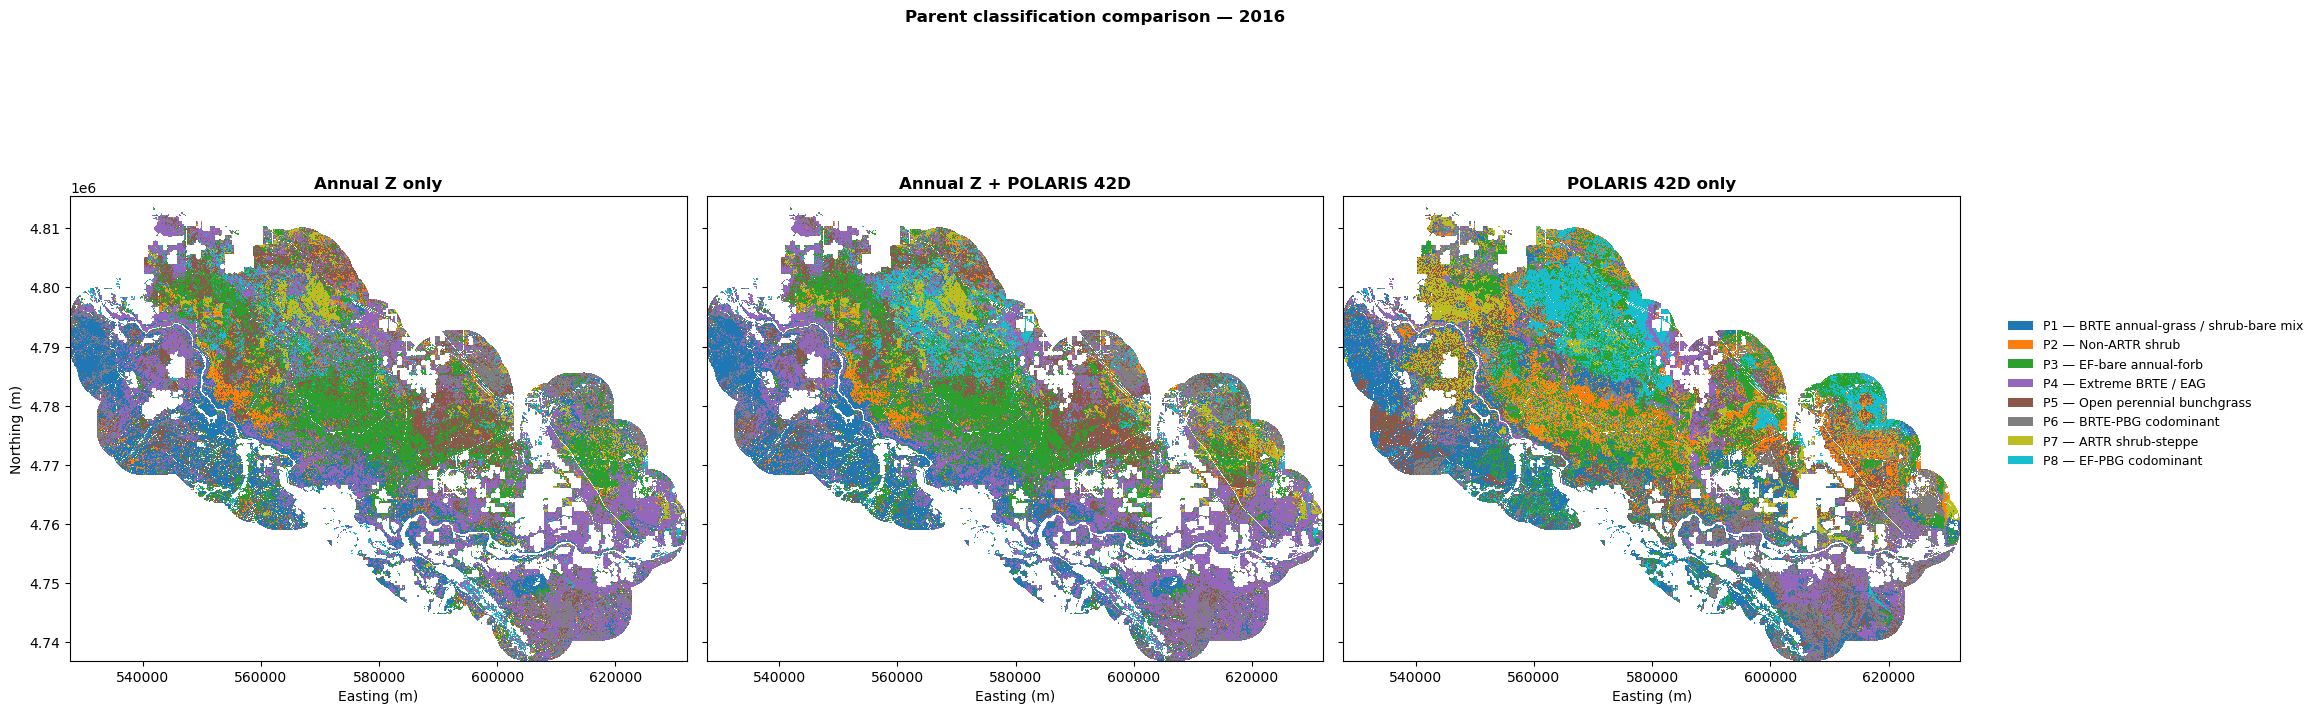

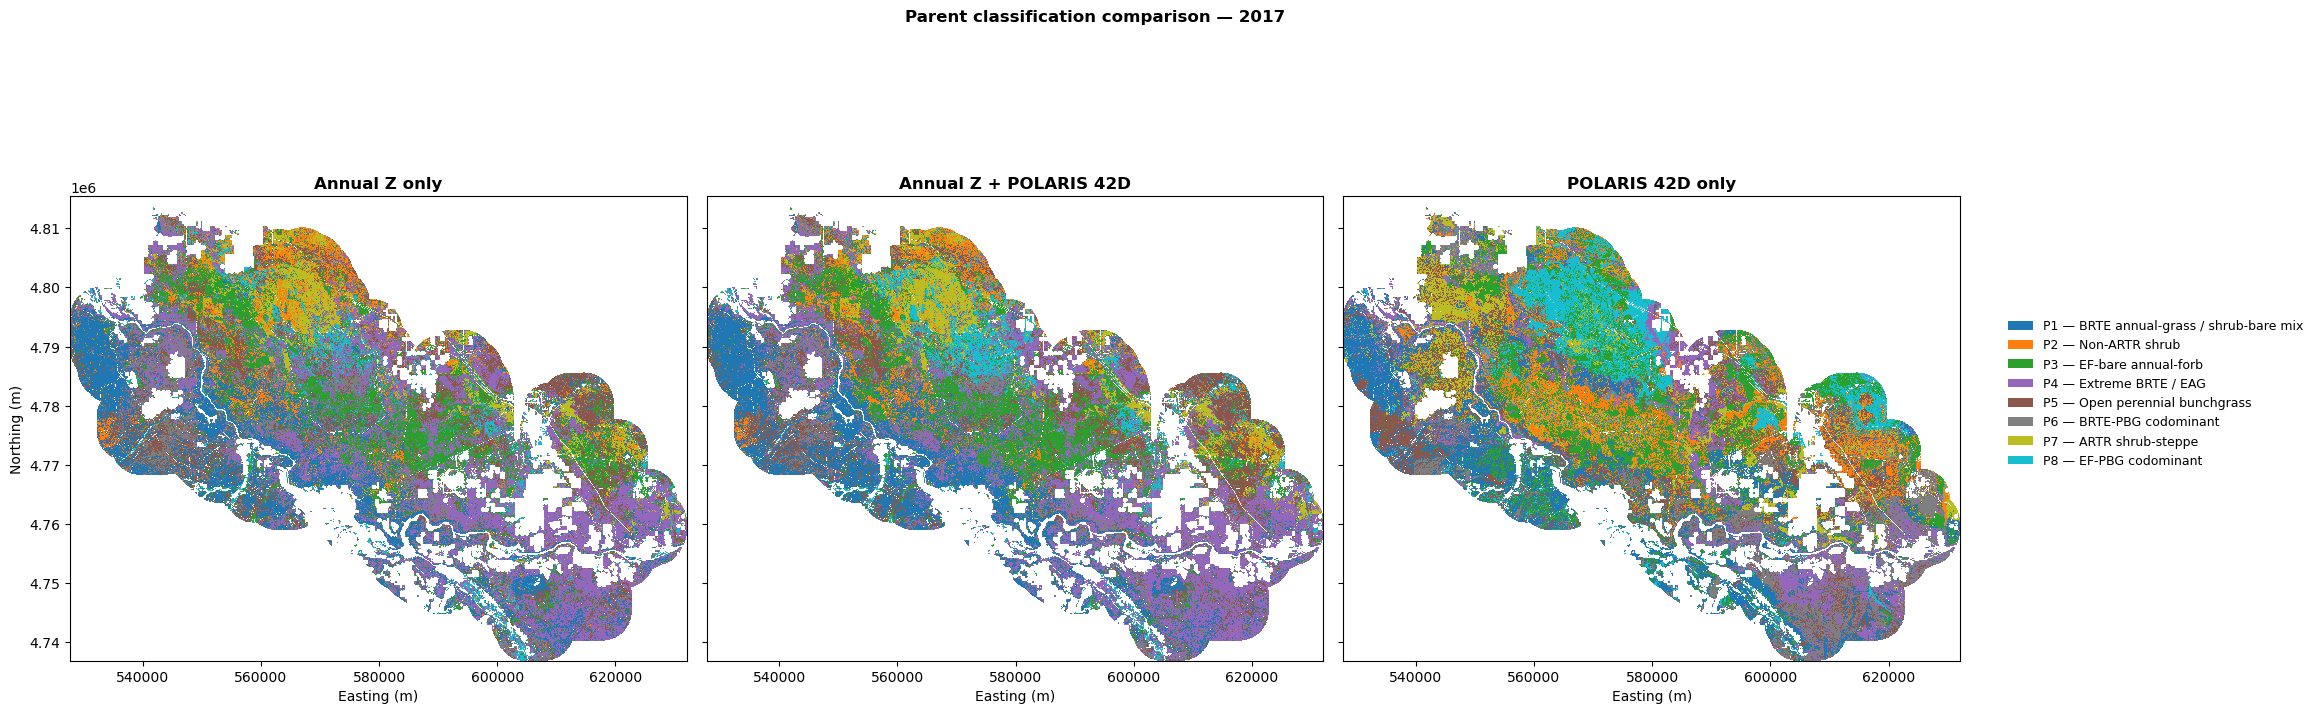

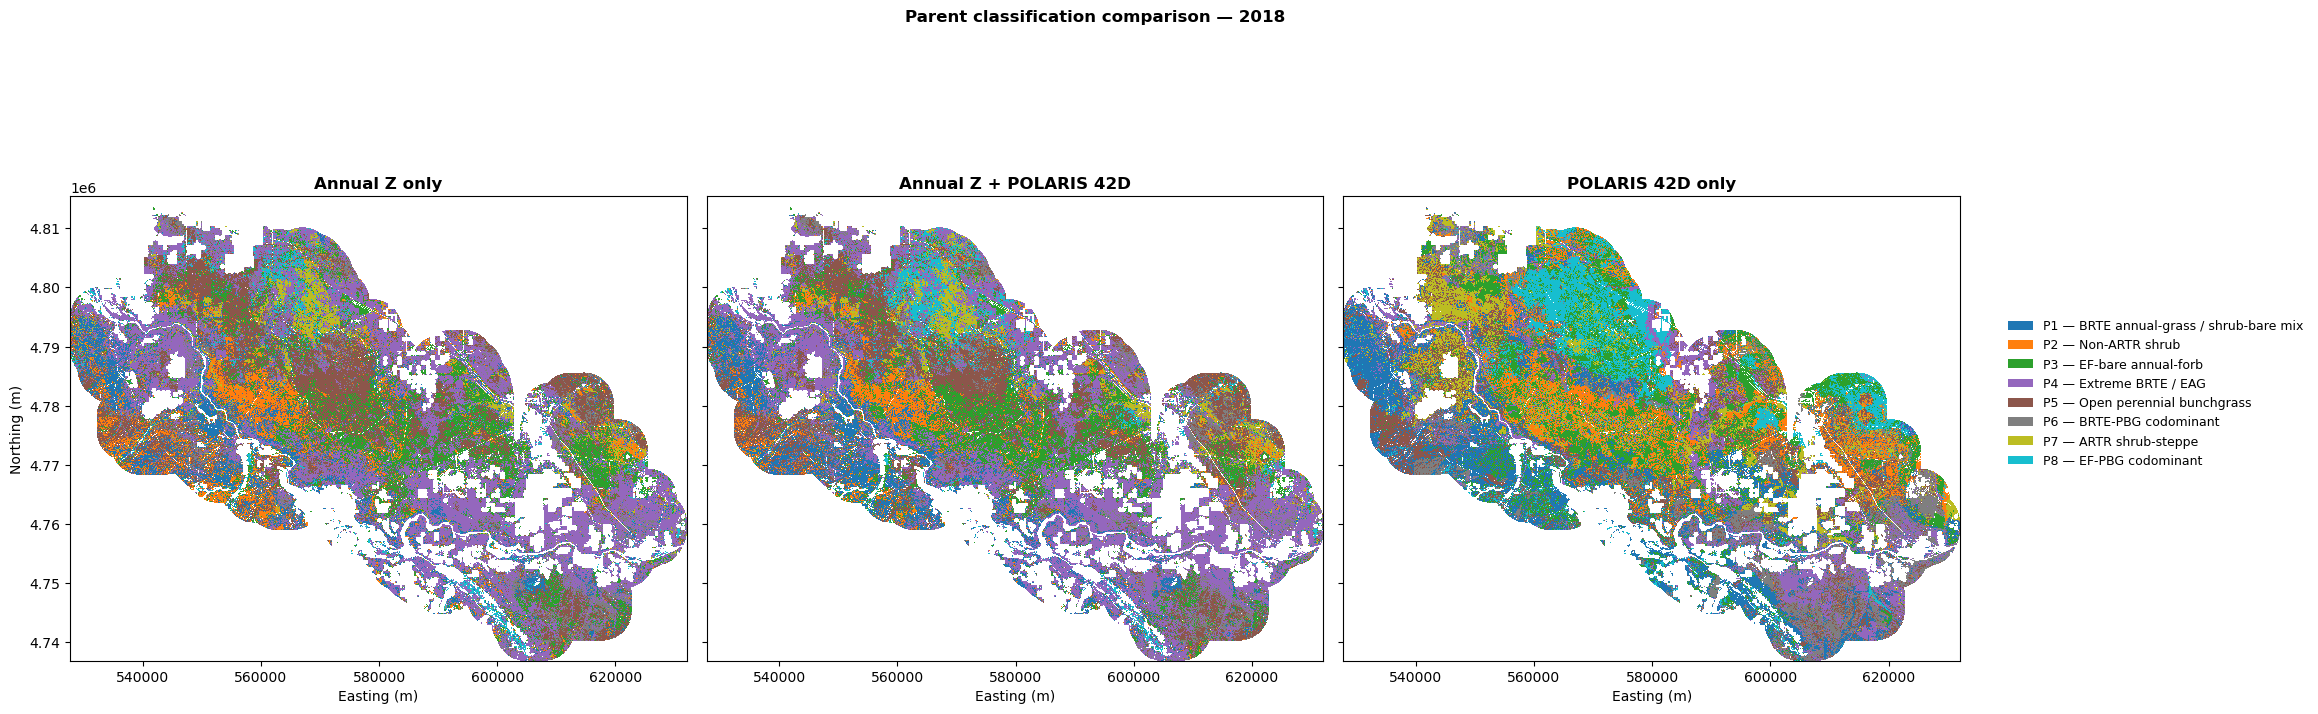

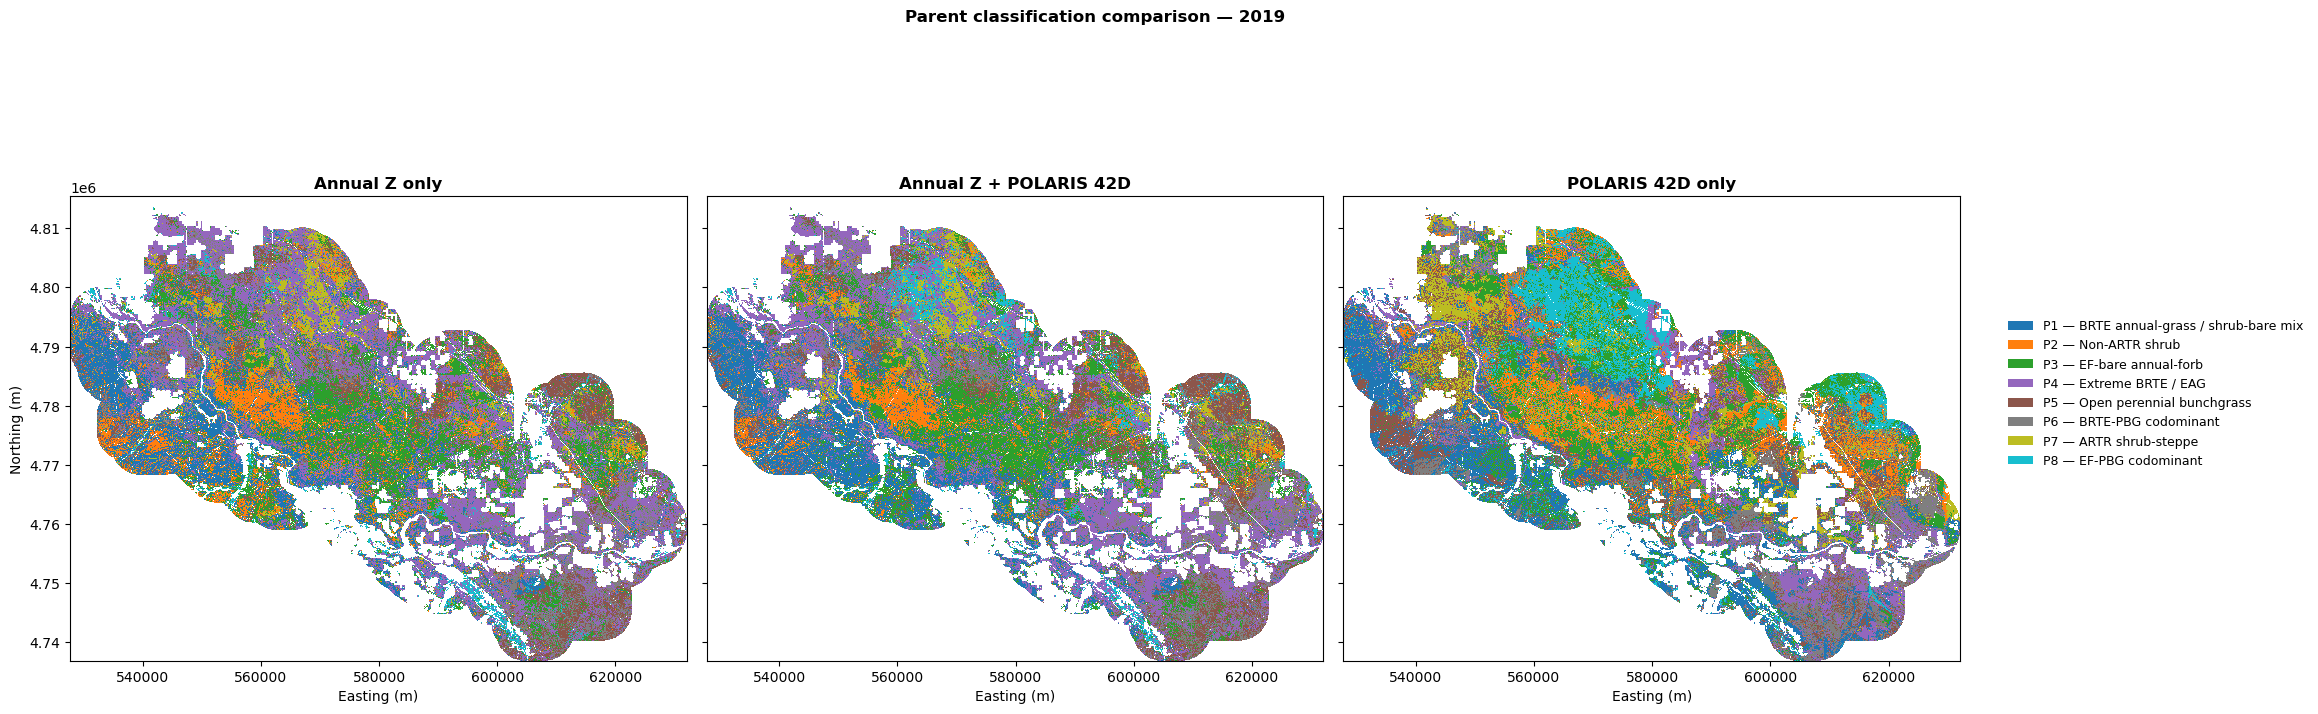

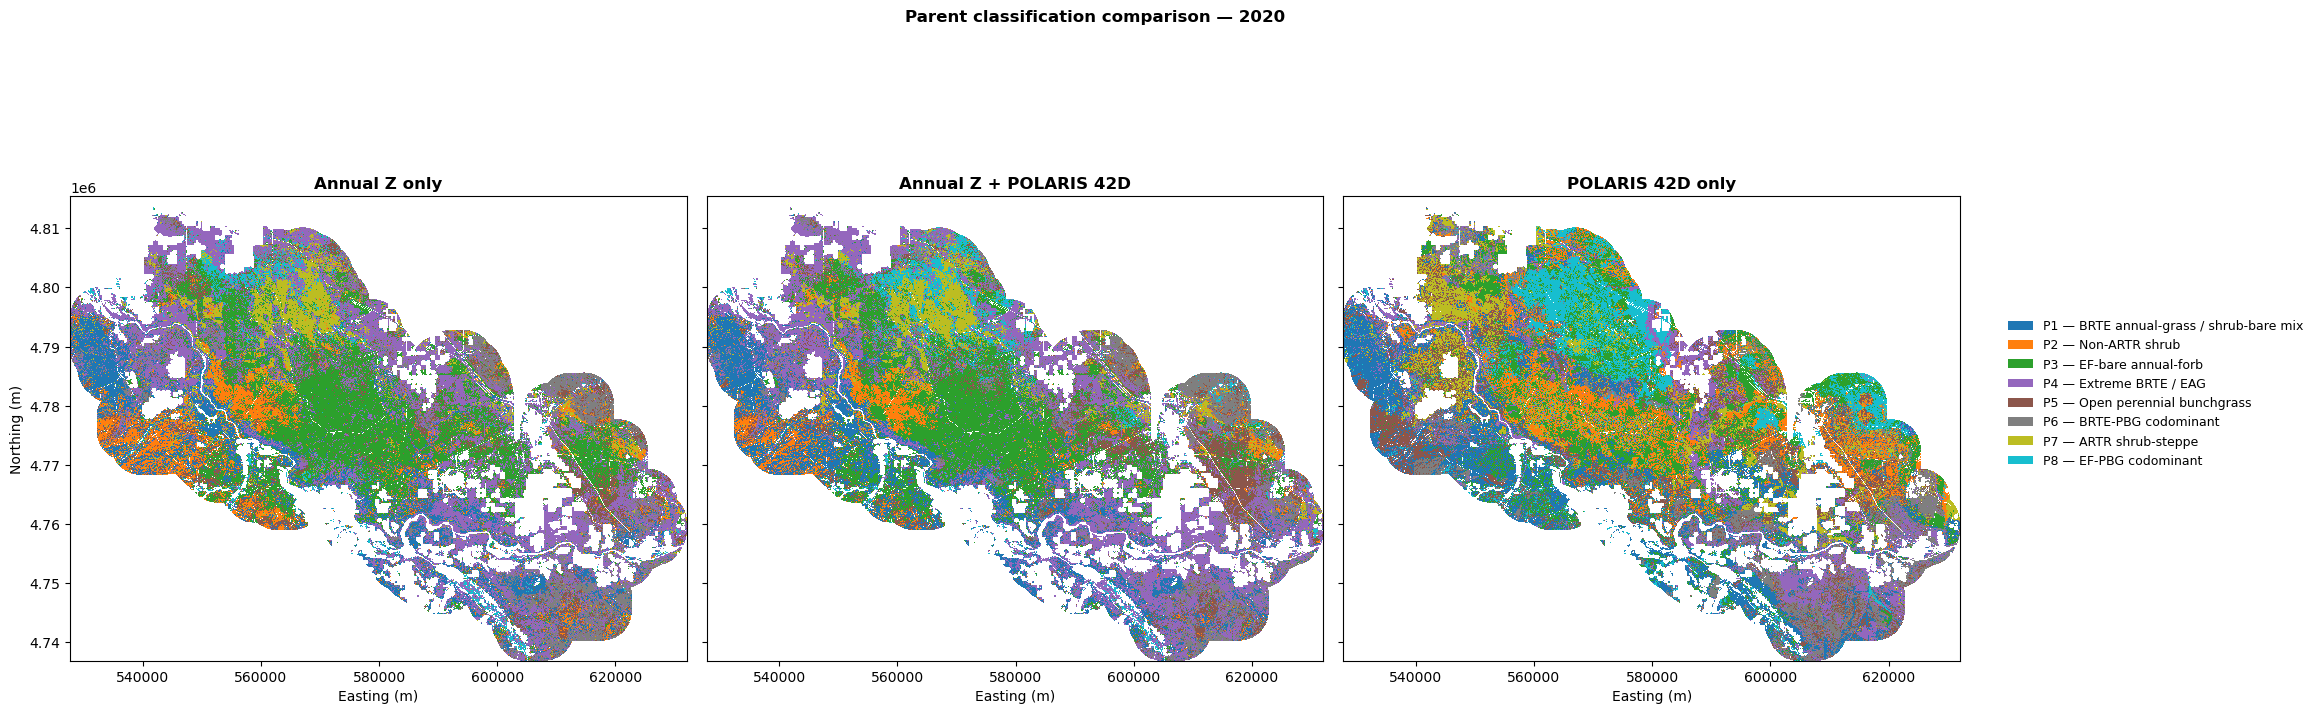

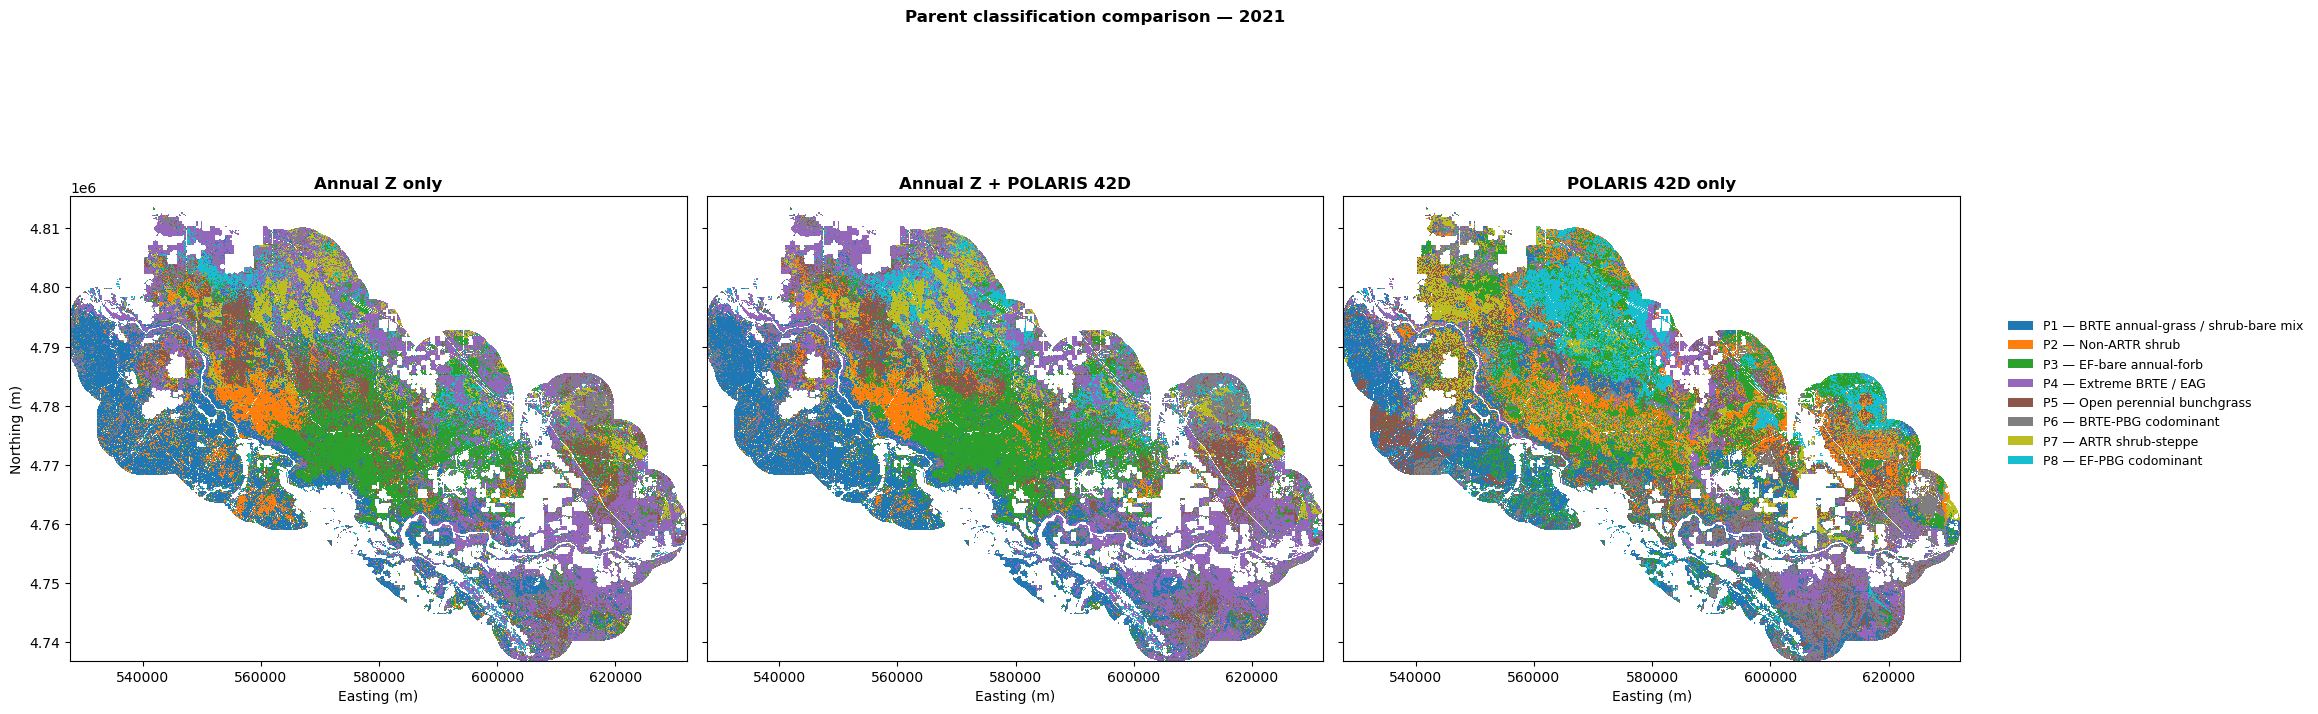

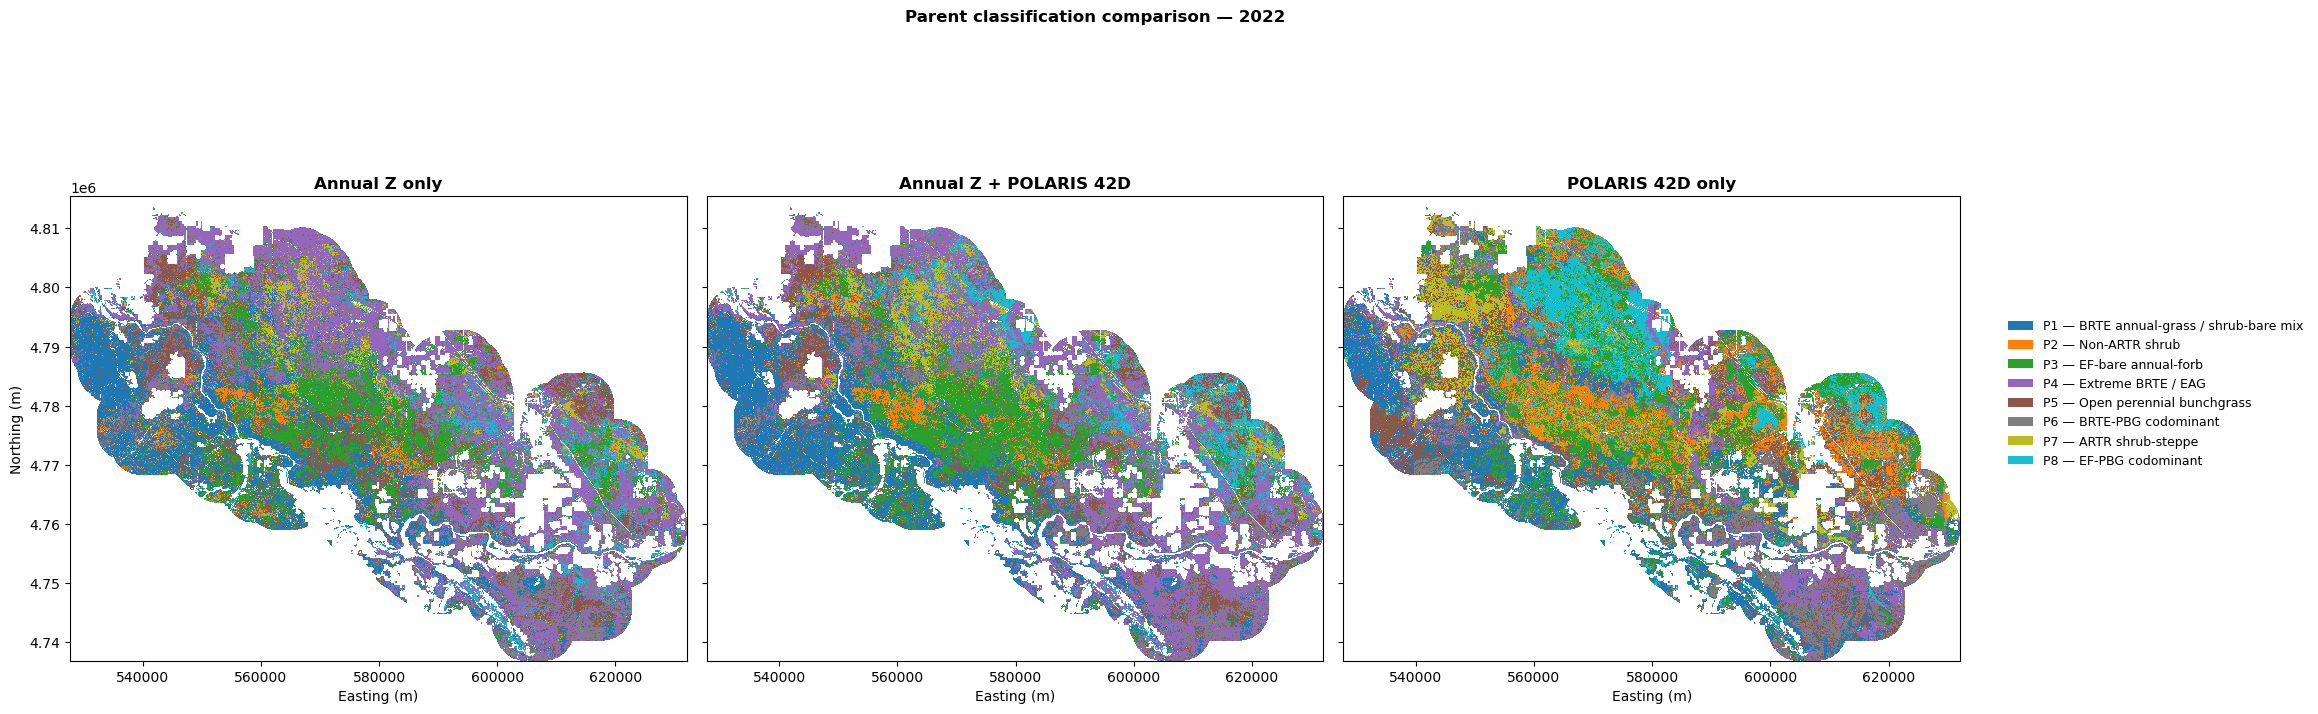

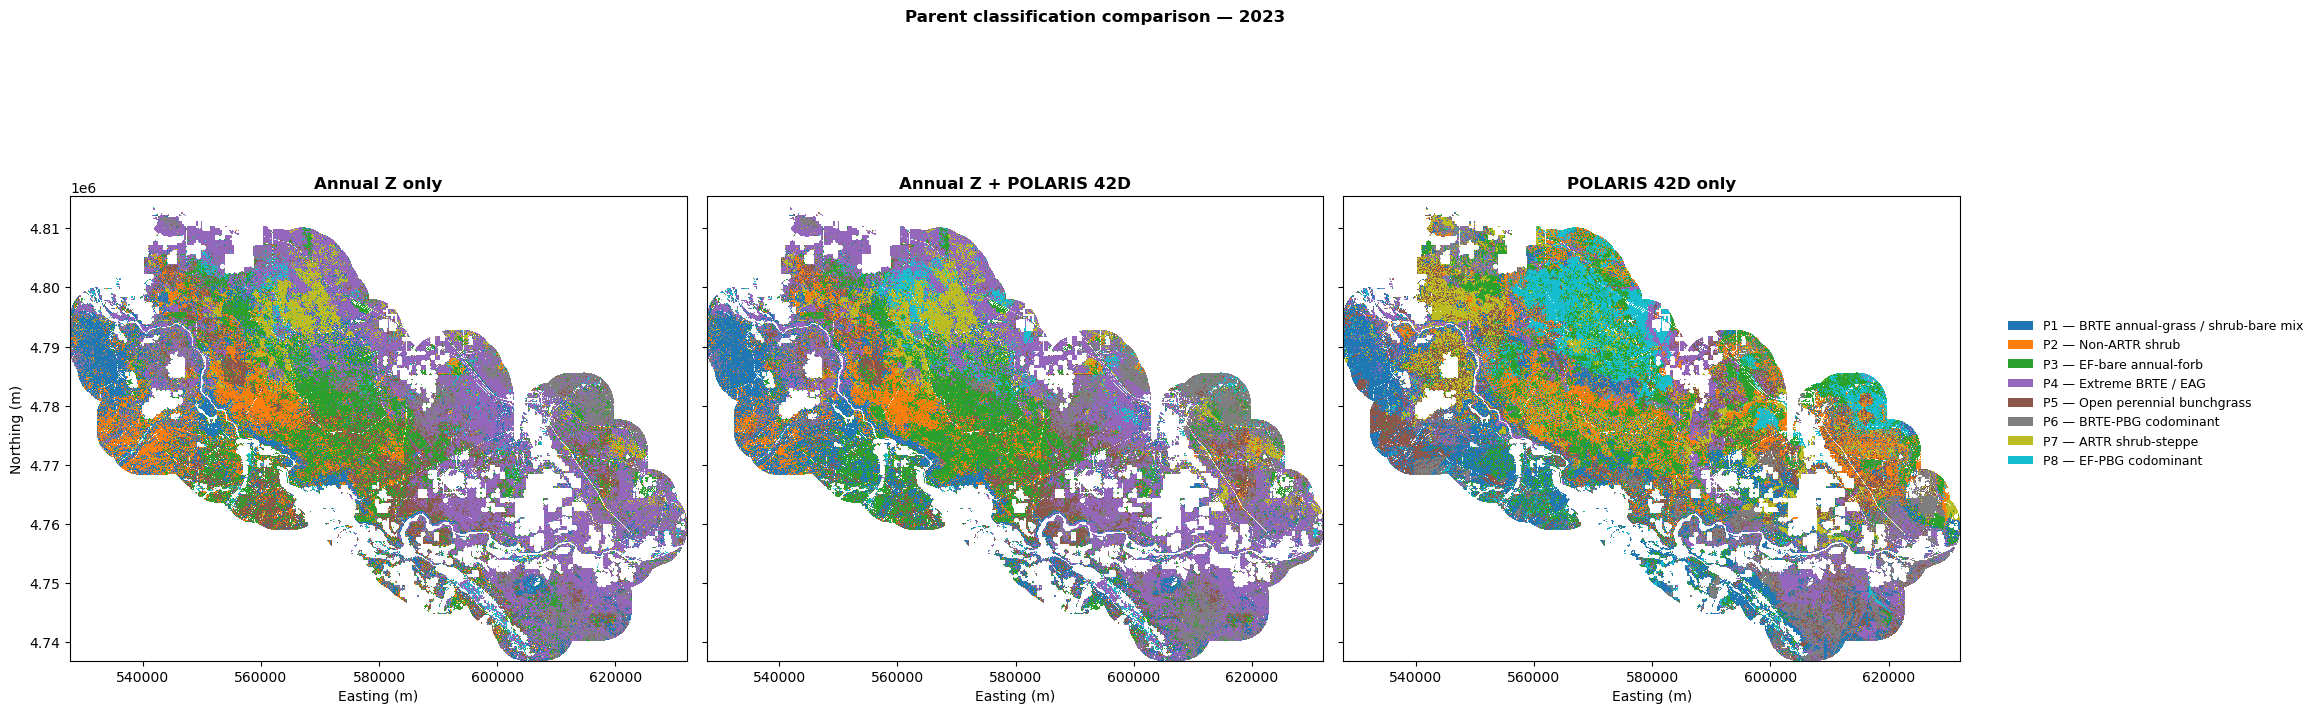

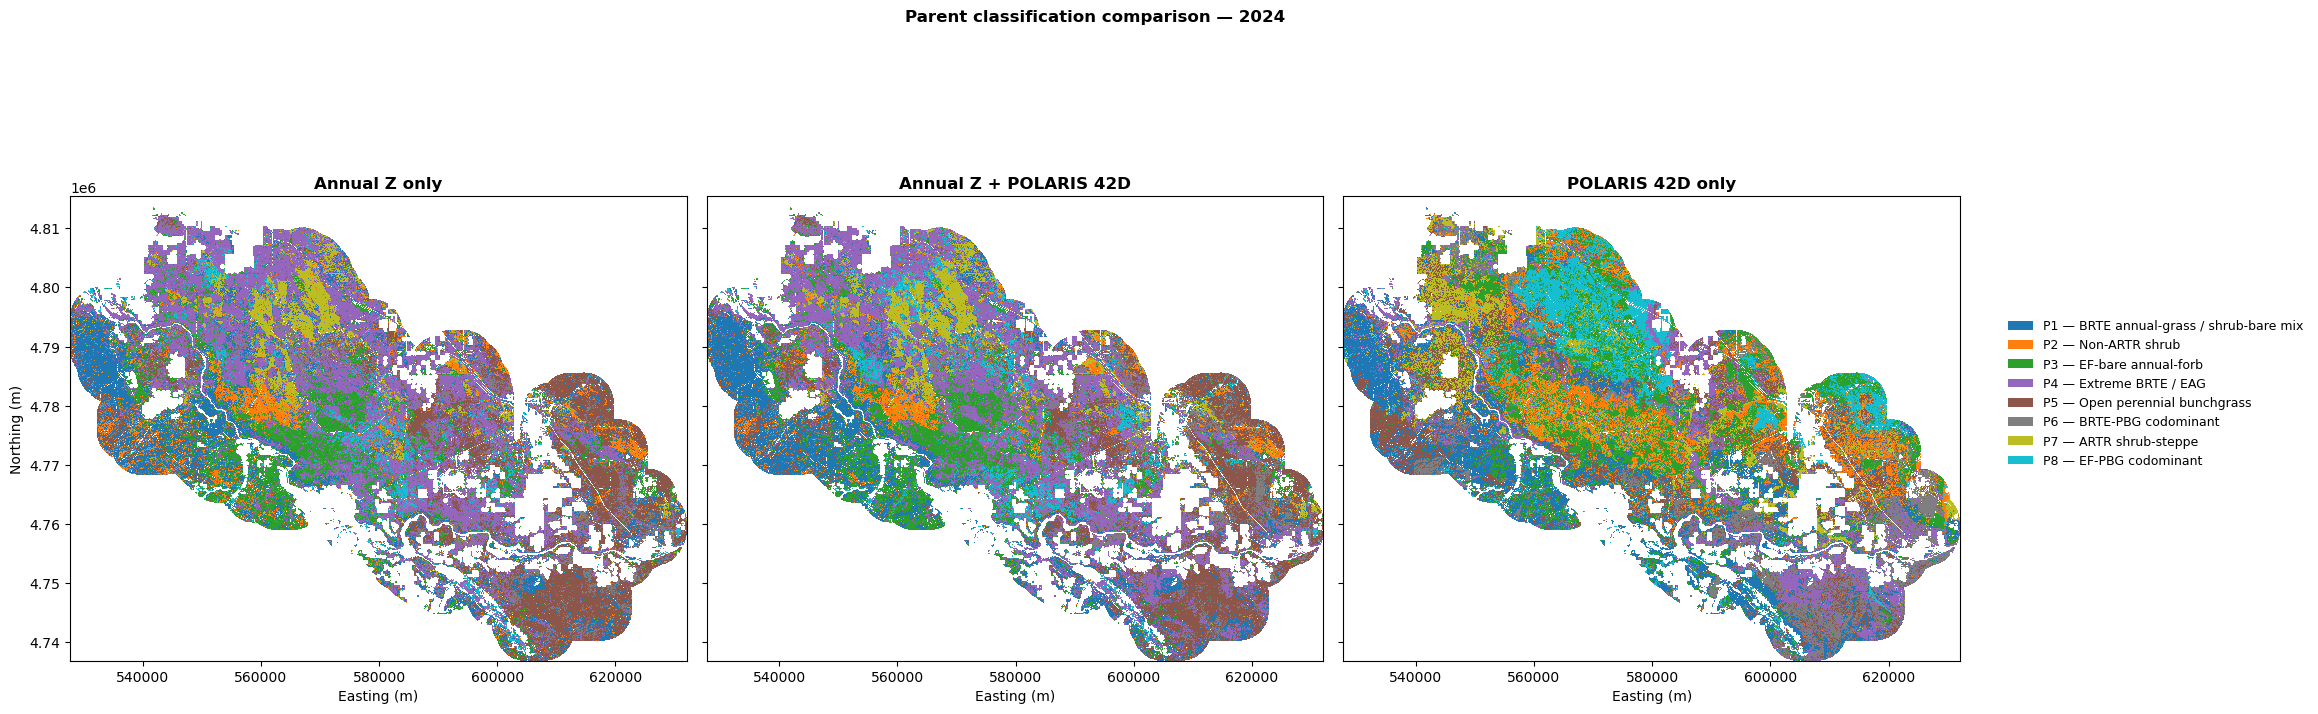

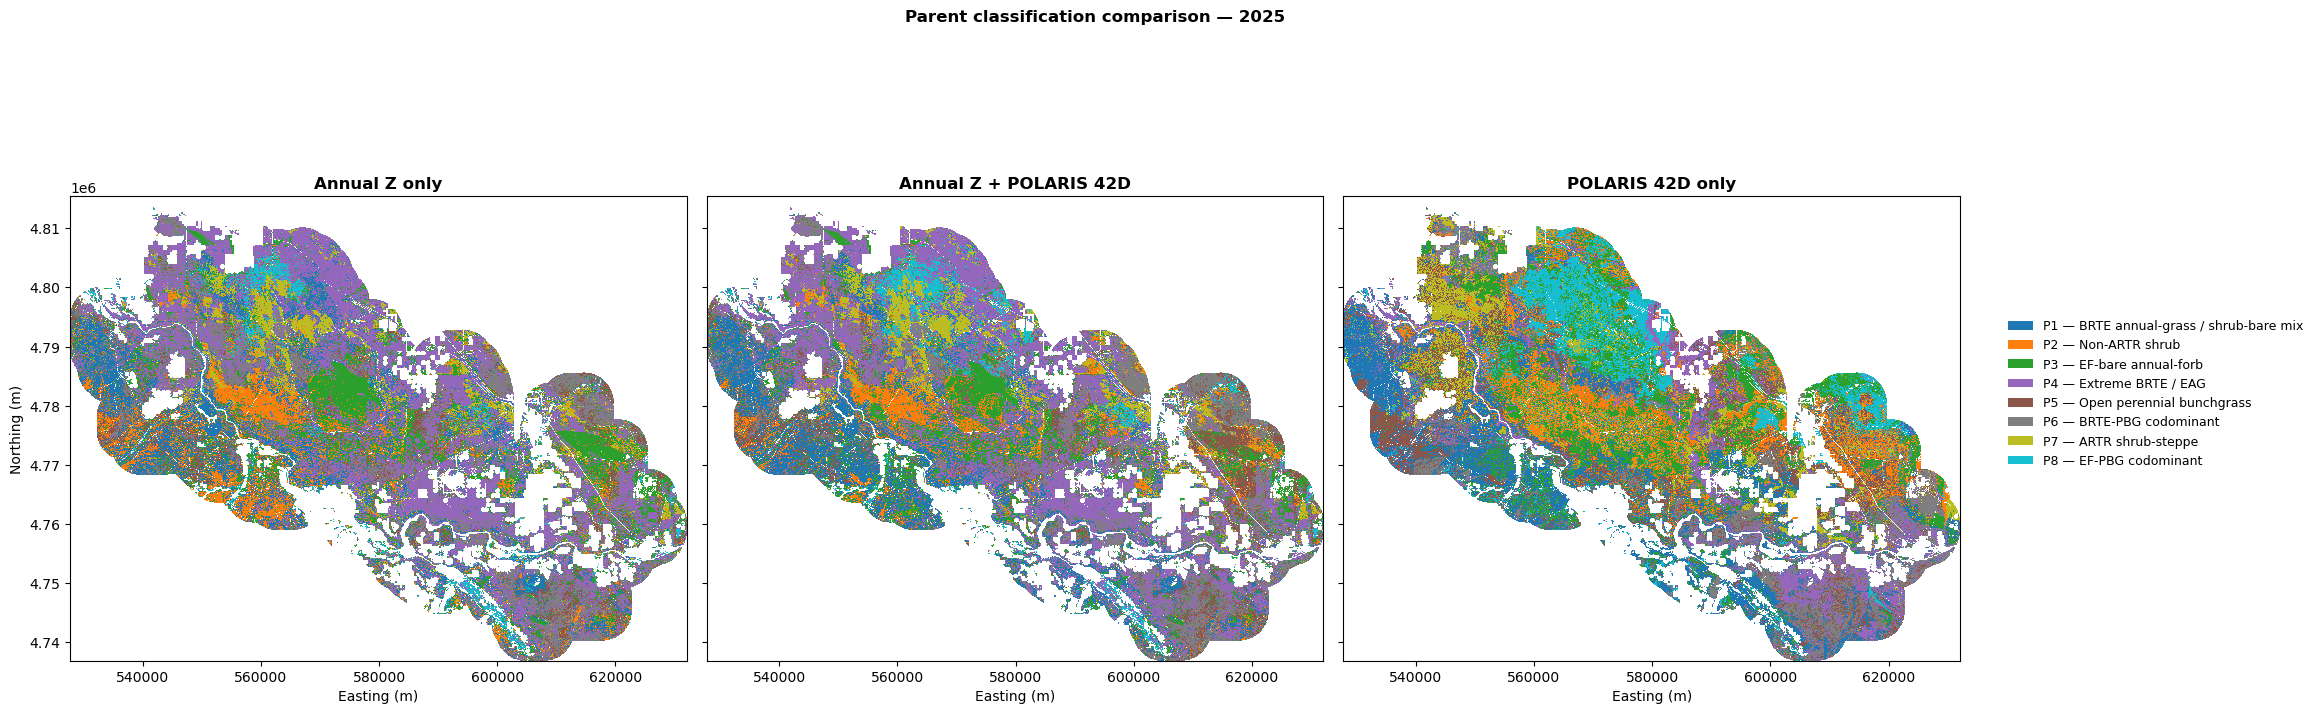

In [16]:
# =============================================================================
# 15. MAP COMPARISON FIGURES
# =============================================================================

PARENT_LABELS = {
    1: "BRTE annual-grass / shrub-bare mix",
    2: "Non-ARTR shrub",
    3: "EF-bare annual-forb",
    4: "Extreme BRTE / EAG",
    5: "Open perennial bunchgrass",
    6: "BRTE-PBG codominant",
    7: "ARTR shrub-steppe",
    8: "EF-PBG codominant",
}


cmap = plt.get_cmap(
    "tab10",
    8,
)

class_norm = BoundaryNorm(
    np.arange(
        0.5,
        9.5,
        1,
    ),
    cmap.N,
)


legend_handles = [
    Patch(
        facecolor=cmap(
            parent - 1
        ),
        edgecolor="none",
        label=(
            f"P{parent} — "
            f"{PARENT_LABELS[parent]}"
        ),
    )
    for parent in VEG_PARENT_CODES
]


if RUN_MAPPING:

    p42_class_path, _ = output_paths_42(
        "polaris_42d"
    )


    with rasterio.open(
        p42_class_path
    ) as src:

        static_p42 = src.read(
            1,
            masked=False,
        )

        bounds = src.bounds


    for year in YEARS_TO_MAP:

        z_class_path, _ = old_z_paths(
            year
        )

        combined_class_path, _ = output_paths_42(
            "z_plus_polaris_42d",
            year,
        )


        with rasterio.open(
            z_class_path
        ) as src:

            z_map = src.read(
                1,
                masked=False,
            )


        with rasterio.open(
            combined_class_path
        ) as src:

            zp42_map = src.read(
                1,
                masked=False,
            )


        arrays = {
            "z": z_map,
            "z_plus_polaris_42d": zp42_map,
            "polaris_42d": static_p42,
        }


        fig, axes = plt.subplots(
            1,
            3,
            figsize=(
                22,
                8,
            ),
            sharex=True,
            sharey=True,
        )


        panel_titles = {
            "z": "Annual Z only",
            "z_plus_polaris_42d": "Annual Z + POLARIS 42D",
            "polaris_42d": "POLARIS 42D only",
        }


        for ax, representation in zip(
            axes,
            [
                "z",
                "z_plus_polaris_42d",
                "polaris_42d",
            ],
        ):

            arr = np.ma.masked_where(
                ~np.isin(
                    arrays[
                        representation
                    ],
                    VEG_PARENT_CODES,
                ),
                arrays[
                    representation
                ],
            )


            ax.imshow(
                arr,
                cmap=cmap,
                norm=class_norm,
                extent=[
                    bounds.left,
                    bounds.right,
                    bounds.bottom,
                    bounds.top,
                ],
                interpolation="nearest",
            )


            ax.set_title(
                panel_titles[
                    representation
                ],
                fontweight="bold",
            )

            ax.set_xlabel(
                "Easting (m)"
            )


        axes[
            0
        ].set_ylabel(
            "Northing (m)"
        )


        fig.suptitle(
            f"Parent classification comparison — {year}",
            fontweight="bold",
        )


        fig.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(
                0.91,
                0.5,
            ),
            frameon=False,
            fontsize=9,
        )


        fig.tight_layout(
            rect=[
                0,
                0,
                0.90,
                0.95,
            ]
        )


        if SAVE_COMPARISON_FIGURES:

            fig.savefig(
                OUTPUT_DIR
                / (
                    f"comparison_Z_POLARIS42_"
                    f"{year}.png"
                ),
                dpi=300,
                bbox_inches="tight",
            )


        plt.show()

        plt.close(
            fig
        )

## 16. True-NCA agreement and uncertainty comparison

This reuses the old Z uncertainty rasters and compares them with the new 42D combined rasters only inside the true NCA.

For each year:

\[
\Delta p_{\max}
=
p_{\max}^{Z+P42}
-
p_{\max}^{Z}
\]

\[
\Delta M
=
M^{Z+P42}
-
M^{Z}
\]

\[
\Delta H_{norm}
=
H_{norm}^{Z+P42}
-
H_{norm}^{Z}.
\]

Improved categorical separation would ideally produce:

- positive \(\Delta p_{\max}\);
- positive \(\Delta M\);
- negative \(\Delta H_{norm}\).

In [17]:
# =============================================================================
# 16. TRUE-NCA AGREEMENT + UNCERTAINTY
# =============================================================================

if RUN_TRUE_NCA_DIAGNOSTICS:

    if not TRUE_NCA_SHP.exists():
        raise FileNotFoundError(
            f"True NCA shapefile not found:\n{TRUE_NCA_SHP}"
        )


    nca = gpd.read_file(
        TRUE_NCA_SHP
    )


    reference_z_class, _ = old_z_paths(
        YEARS_TO_MAP[0]
    )


    with rasterio.open(
        reference_z_class
    ) as ref:

        raster_crs = ref.crs


    if nca.crs != raster_crs:

        nca = nca.to_crs(
            raster_crs
        )


    nca_shapes = [
        geom.__geo_interface__
        for geom in nca.geometry
        if (
            geom is not None
            and not geom.is_empty
        )
    ]


    if not nca_shapes:
        raise ValueError(
            "No valid true-NCA geometries."
        )


    uncertainty_records = []
    agreement_records = []


    for year in YEARS_TO_MAP:

        z_class_path, z_unc_path = old_z_paths(
            year
        )

        zp_class_path, zp_unc_path = output_paths_42(
            "z_plus_polaris_42d",
            year,
        )


        # ---------------------------------------------------------------------
        # CLASS AGREEMENT
        # ---------------------------------------------------------------------

        with rasterio.open(
            z_class_path
        ) as src:

            z_class, z_transform = rio_mask(
                src,
                nca_shapes,
                crop=True,
                filled=True,
                nodata=0,
                all_touched=False,
            )


        with rasterio.open(
            zp_class_path
        ) as src:

            zp_class, zp_transform = rio_mask(
                src,
                nca_shapes,
                crop=True,
                filled=True,
                nodata=0,
                all_touched=False,
            )


        if (
            z_class.shape
            != zp_class.shape
            or z_transform
            != zp_transform
        ):
            raise ValueError(
                f"Class raster mismatch for {year}."
            )


        zc = z_class[
            0
        ]

        zpc = zp_class[
            0
        ]


        valid_class = (
            np.isin(
                zc,
                VEG_PARENT_CODES,
            )
            & np.isin(
                zpc,
                VEG_PARENT_CODES,
            )
        )


        agreement_records.append(
            {
                "Year": year,
                "n_paired_pixels": int(
                    valid_class.sum()
                ),
                "exact_agreement": float(
                    np.mean(
                        zc[
                            valid_class
                        ]
                        == zpc[
                            valid_class
                        ]
                    )
                ),
            }
        )


        # ---------------------------------------------------------------------
        # UNCERTAINTY
        # ---------------------------------------------------------------------

        with rasterio.open(
            z_unc_path
        ) as src:

            z_unc, z_unc_transform = rio_mask(
                src,
                nca_shapes,
                crop=True,
                filled=True,
                nodata=-9999.0,
                all_touched=False,
            )


        with rasterio.open(
            zp_unc_path
        ) as src:

            zp_unc, zp_unc_transform = rio_mask(
                src,
                nca_shapes,
                crop=True,
                filled=True,
                nodata=-9999.0,
                all_touched=False,
            )


        if (
            z_unc.shape
            != zp_unc.shape
            or z_unc_transform
            != zp_unc_transform
        ):
            raise ValueError(
                f"Uncertainty raster mismatch for {year}."
            )


        z_unc = z_unc.astype(
            np.float64
        )

        zp_unc = zp_unc.astype(
            np.float64
        )


        z_unc[
            z_unc
            == -9999.0
        ] = np.nan

        zp_unc[
            zp_unc
            == -9999.0
        ] = np.nan


        valid_unc = (
            np.isfinite(
                z_unc
            ).all(
                axis=0
            )
            & np.isfinite(
                zp_unc
            ).all(
                axis=0
            )
        )


        log_k = np.log(
            len(
                VEG_PARENT_CODES
            )
        )


        z_pmax = z_unc[
            0
        ][
            valid_unc
        ]

        zp_pmax = zp_unc[
            0
        ][
            valid_unc
        ]

        z_margin = z_unc[
            1
        ][
            valid_unc
        ]

        zp_margin = zp_unc[
            1
        ][
            valid_unc
        ]

        z_entropy_norm = (
            z_unc[
                2
            ][
                valid_unc
            ]
            / log_k
        )

        zp_entropy_norm = (
            zp_unc[
                2
            ][
                valid_unc
            ]
            / log_k
        )


        uncertainty_records.append(
            {
                "Year": year,
                "n_pixels": int(
                    valid_unc.sum()
                ),

                "z_mean_pmax": float(
                    z_pmax.mean()
                ),

                "z_plus_p42_mean_pmax": float(
                    zp_pmax.mean()
                ),

                "delta_mean_pmax": float(
                    zp_pmax.mean()
                    - z_pmax.mean()
                ),

                "z_mean_margin": float(
                    z_margin.mean()
                ),

                "z_plus_p42_mean_margin": float(
                    zp_margin.mean()
                ),

                "delta_mean_margin": float(
                    zp_margin.mean()
                    - z_margin.mean()
                ),

                "z_mean_normalized_entropy": float(
                    z_entropy_norm.mean()
                ),

                "z_plus_p42_mean_normalized_entropy": float(
                    zp_entropy_norm.mean()
                ),

                "delta_mean_normalized_entropy": float(
                    zp_entropy_norm.mean()
                    - z_entropy_norm.mean()
                ),
            }
        )


    agreement_df = pd.DataFrame(
        agreement_records
    )

    uncertainty_df = pd.DataFrame(
        uncertainty_records
    )


    agreement_df.to_csv(
        OUTPUT_DIR
        / "trueNCA_Z_vs_ZP42_map_agreement.csv",
        index=False,
    )

    uncertainty_df.to_csv(
        OUTPUT_DIR
        / "trueNCA_Z_vs_ZP42_uncertainty_summary.csv",
        index=False,
    )


    print(
        "True-NCA Z vs Z+P42 map agreement:"
    )

    display(
        agreement_df.round(
            4
        )
    )


    print(
        "\nTrue-NCA uncertainty changes:"
    )

    display(
        uncertainty_df.round(
            4
        )
    )

True-NCA Z vs Z+P42 map agreement:


,Year,n_paired_pixels,exact_agreement
0,2016,22009780,0.7846
1,2017,22049257,0.7577
2,2018,22048888,0.7950
3,2019,22057243,0.7590
4,2020,22065310,0.7829
5,2021,22062913,0.7879
6,2022,22058530,0.7358
7,2023,22068032,0.7689
8,2024,22069019,0.7731
9,2025,22062129,0.7434



True-NCA uncertainty changes:


,Year,n_pixels,z_mean_pmax,z_plus_p42_mean_pmax,delta_mean_pmax,z_mean_margin,z_plus_p42_mean_margin,delta_mean_margin,z_mean_normalized_entropy,z_plus_p42_mean_normalized_entropy,delta_mean_normalized_entropy
0,2016,22009780,0.3773,0.3616,-0.0157,0.1632,0.1537,-0.0095,0.8025,0.8264,0.0238
1,2017,22049257,0.3343,0.3214,-0.0129,0.1233,0.1193,-0.0040,0.8435,0.8628,0.0193
2,2018,22048888,0.3832,0.3591,-0.0241,0.1748,0.1534,-0.0214,0.8005,0.8301,0.0296
3,2019,22057243,0.3440,0.3312,-0.0127,0.1311,0.1234,-0.0077,0.8317,0.8505,0.0188
4,2020,22065310,0.3743,0.3644,-0.0098,0.1601,0.1589,-0.0012,0.8055,0.8248,0.0193
5,2021,22062913,0.3795,0.3665,-0.0129,0.1606,0.1587,-0.0019,0.7969,0.8196,0.0227
6,2022,22058530,0.3355,0.3259,-0.0096,0.1182,0.1197,0.0015,0.8351,0.8538,0.0187
7,2023,22068032,0.3645,0.3494,-0.0150,0.1471,0.1393,-0.0078,0.8102,0.8329,0.0227
8,2024,22069019,0.3389,0.3241,-0.0148,0.1265,0.1187,-0.0078,0.8379,0.8591,0.0212
9,2025,22062129,0.3622,0.3402,-0.0220,0.1365,0.1215,-0.0150,0.8052,0.8343,0.0291


## 17. True-NCA temporal persistence

For each representation, adjacent-year class changes are counted over 2016–2025:

\[
\text{persistence}
=
1-
\frac{\#\text{adjacent-year changes}}
{\#\text{valid adjacent-year transitions}}.
\]

The goal is not maximal stability. The useful result would be increased persistence **without** destroying real annual variation, particularly if OOF/spatial validation and uncertainty also improve.

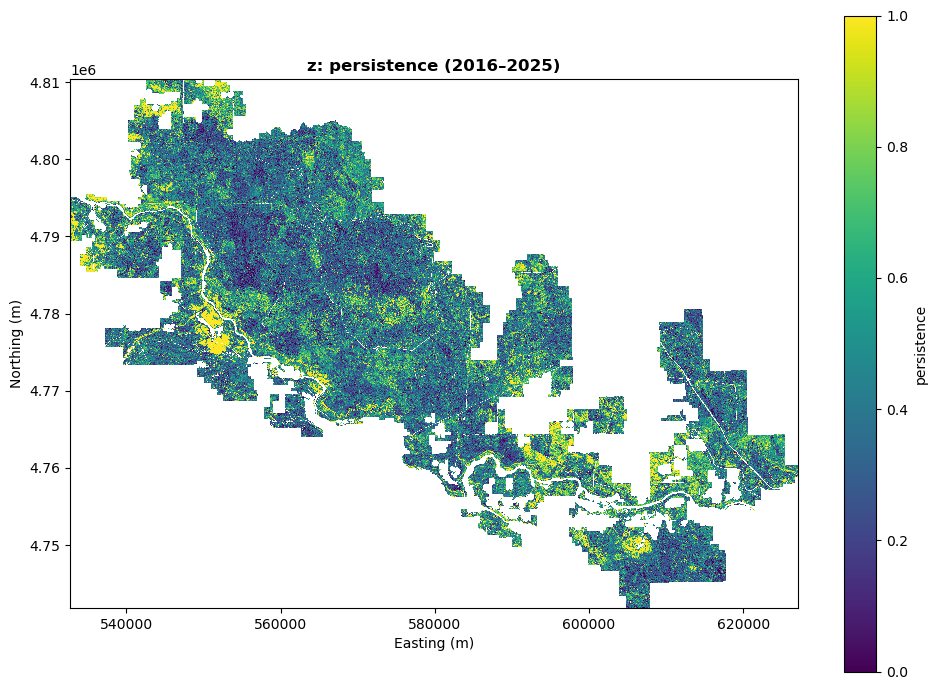

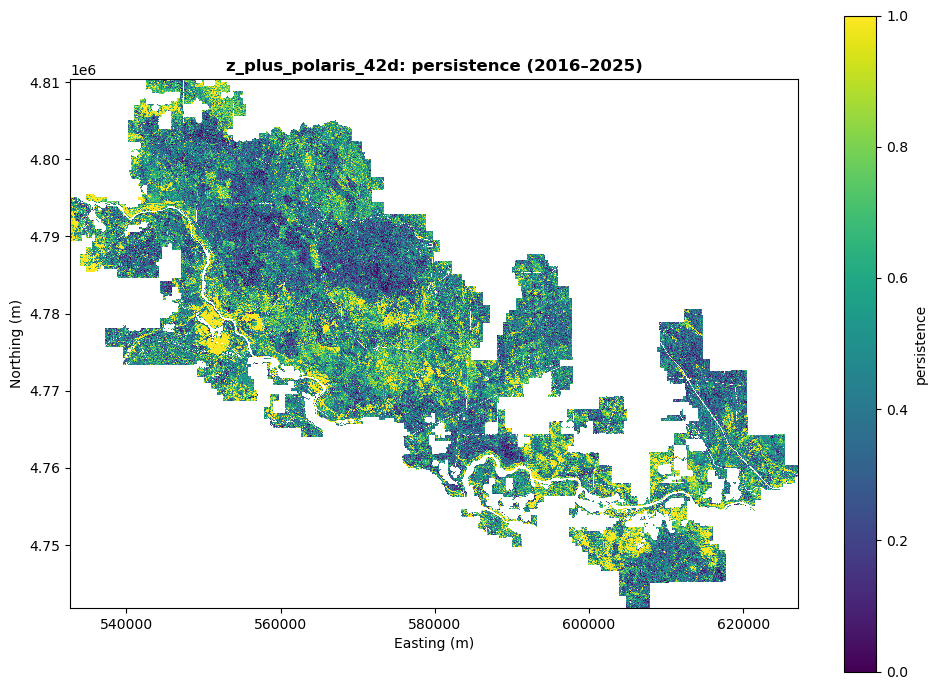

True-NCA temporal persistence:


,representation,n_pixels,mean_persistence,median_persistence,mean_adjacent_year_changes
0,z,22072805,0.4517,0.4444,4.9296
1,z_plus_polaris_42d,22072805,0.5106,0.4444,4.3994



Mean persistence change (Z+P42 minus Z): 0.059


In [18]:
# =============================================================================
# 17. TRUE-NCA TEMPORAL PERSISTENCE
# =============================================================================

if RUN_TRUE_NCA_DIAGNOSTICS:

    persistence_records = []


    for representation in [
        "z",
        "z_plus_polaris_42d",
    ]:

        previous = None
        change_count = None
        transition_count = None


        for year in YEARS_TO_MAP:

            if representation == "z":

                class_path, _ = old_z_paths(
                    year
                )

            else:

                class_path, _ = output_paths_42(
                    representation,
                    year,
                )


            with rasterio.open(
                class_path
            ) as src:

                clipped, transform = rio_mask(
                    src,
                    nca_shapes,
                    crop=True,
                    filled=True,
                    nodata=0,
                    all_touched=False,
                )


            current = clipped[
                0
            ]


            if previous is None:

                change_count = np.zeros(
                    current.shape,
                    dtype=np.uint8,
                )

                transition_count = np.zeros(
                    current.shape,
                    dtype=np.uint8,
                )

            else:

                valid_transition = (
                    np.isin(
                        previous,
                        VEG_PARENT_CODES,
                    )
                    & np.isin(
                        current,
                        VEG_PARENT_CODES,
                    )
                )


                transition_count[
                    valid_transition
                ] += 1


                changed = (
                    valid_transition
                    & (
                        previous
                        != current
                    )
                )


                change_count[
                    changed
                ] += 1


            previous = current


        valid_persistence = (
            transition_count
            > 0
        )


        persistence = np.full(
            transition_count.shape,
            np.nan,
            dtype=np.float32,
        )


        persistence[
            valid_persistence
        ] = (
            1.0
            -
            (
                change_count[
                    valid_persistence
                ].astype(
                    np.float32
                )
                /
                transition_count[
                    valid_persistence
                ].astype(
                    np.float32
                )
            )
        )


        persistence_records.append(
            {
                "representation": representation,
                "n_pixels": int(
                    valid_persistence.sum()
                ),
                "mean_persistence": float(
                    np.nanmean(
                        persistence
                    )
                ),
                "median_persistence": float(
                    np.nanmedian(
                        persistence
                    )
                ),
                "mean_adjacent_year_changes": float(
                    change_count[
                        valid_persistence
                    ].mean()
                ),
            }
        )


        # Diagnostic figure.
        fig, ax = plt.subplots(
            figsize=(
                10,
                7,
            )
        )


        im = ax.imshow(
            np.ma.masked_invalid(
                persistence
            ),
            extent=[
                transform.c,
                (
                    transform.c
                    + transform.a
                    * persistence.shape[
                        1
                    ]
                ),
                (
                    transform.f
                    + transform.e
                    * persistence.shape[
                        0
                    ]
                ),
                transform.f,
            ],
            vmin=0,
            vmax=1,
            interpolation="nearest",
        )


        ax.set_title(
            f"{representation}: persistence (2016–2025)",
            fontweight="bold",
        )

        ax.set_xlabel(
            "Easting (m)"
        )

        ax.set_ylabel(
            "Northing (m)"
        )


        fig.colorbar(
            im,
            ax=ax,
            label="persistence",
        )


        fig.tight_layout()


        fig.savefig(
            OUTPUT_DIR
            / (
                f"trueNCA_persistence_"
                f"{representation}.png"
            ),
            dpi=300,
            bbox_inches="tight",
        )


        plt.show()

        plt.close(
            fig
        )


    persistence_df = pd.DataFrame(
        persistence_records
    )


    persistence_df.to_csv(
        OUTPUT_DIR
        / "trueNCA_temporal_persistence_summary.csv",
        index=False,
    )


    print(
        "True-NCA temporal persistence:"
    )

    display(
        persistence_df.round(
            4
        )
    )


    if {
        "z",
        "z_plus_polaris_42d",
    }.issubset(
        set(
            persistence_df[
                "representation"
            ]
        )
    ):

        p_lookup = persistence_df.set_index(
            "representation"
        )

        delta_persistence = (
            p_lookup.loc[
                "z_plus_polaris_42d",
                "mean_persistence",
            ]
            -
            p_lookup.loc[
                "z",
                "mean_persistence",
            ]
        )

        print(
            "\nMean persistence change "
            "(Z+P42 minus Z):",
            round(
                float(
                    delta_persistence
                ),
                4,
            ),
        )

## Interpretation

This notebook is intended to answer a narrow question:

> Does retaining the full depth profile while expanding from texture-only POLARIS to all seven soil-property families improve the parent-state RF?

The clean comparison is:

\[
Z+P_{18}
\quad\text{vs}\quad
Z+P_{42}.
\]

Evidence favoring 42D is strongest if it improves several domains simultaneously:

1. grouped OOF accuracy / balanced accuracy / macro F1;
2. LOYO performance;
3. classwise F1 without severe tradeoffs;
4. probability margin and/or normalized entropy;
5. spatial CV at 2 km and 5 km in the separate spatial-CV notebook.

The 42D model should **not** be preferred merely because it makes maps smoother or more persistent.

If 42D is effectively tied with 18D, the 18D texture profile remains preferable on parsimony grounds.  
If 42D materially exceeds 18D under spatial CV, that supports the interpretation that additional depth-explicit edaphic domains contain transferable ecological information.